# Load rw neighborhood

In [1]:
import pandas as pd
import anndata as ad
import argparse
import os
import numpy as np
import scipy.sparse as sp

def load_bptf_results(results_dir):
    """Load BPTF results from directory"""
    print(f"Loading BPTF results from: {results_dir}")
    
    # Load factor matrices
    patch_loadings = np.load(os.path.join(results_dir, 'patch_loadings.npy'))
    lri_factors = np.load(os.path.join(results_dir, 'lri_factors.npy'))
    
    # Load detailed analysis
    patch_motifs = pd.read_csv(os.path.join(results_dir, 'patch_motifs.csv'))
    lri_motifs = pd.read_csv(os.path.join(results_dir, 'lri_motifs.csv'))
    
    print(f"Loaded results:")
    print(f"  - Patch loadings: {patch_loadings.shape}")
    print(f"  - LRI factors: {lri_factors.shape}")
    
    return {
        'patch_loadings': patch_loadings,
        'lri_factors': lri_factors,
        'patch_motifs': patch_motifs,
        'lri_motifs': lri_motifs
    }

In [ ]:
randomwalk = load_bptf_results('../results/ES_random_walk/bptf')
patch = load_bptf_results('../results/ES_cellphone_15/bptf_42')
patch_array, neigh_array = patch['lri_factors'], randomwalk['lri_factors']

Loading BPTF results from: ../results/ES_random_walk/bptf
Loaded results:
  - Patch loadings: (78943, 15)
  - LRI factors: (15, 166035)
Loading BPTF results from: ../results/ES_cellphone_15/bptf_42
Loaded results:
  - Patch loadings: (90538, 15)
  - LRI factors: (15, 166035)


In [13]:
randomwalk.keys()

dict_keys(['patch_loadings', 'lri_factors', 'patch_motifs', 'lri_motifs'])

In [57]:
patch_array, neigh_array = patch['lri_factors'], randomwalk['lri_factors']

In [26]:
print(patch_array.shape)
patch_array

(15, 166035)


array([[1.26677856e-06, 1.26677856e-06, 1.26677856e-06, ...,
        1.26677869e-06, 1.26703819e-06, 1.26677856e-06],
       [2.22115950e-06, 2.22115950e-06, 2.22115950e-06, ...,
        2.22116012e-06, 2.22115963e-06, 2.22115950e-06],
       [1.87490291e-06, 1.87490292e-06, 1.87490291e-06, ...,
        4.11770252e-02, 1.87490292e-06, 1.87490291e-06],
       ...,
       [2.43416189e-06, 2.45001554e-06, 2.43397091e-06, ...,
        2.43397171e-06, 2.43397091e-06, 2.43397091e-06],
       [1.68977965e-06, 1.68977965e-06, 1.68977965e-06, ...,
        1.68977993e-06, 1.68977965e-06, 1.68977965e-06],
       [1.57684138e-06, 1.57684138e-06, 1.57684138e-06, ...,
        1.57684162e-06, 1.57686329e-06, 1.57684138e-06]])

# Similarity

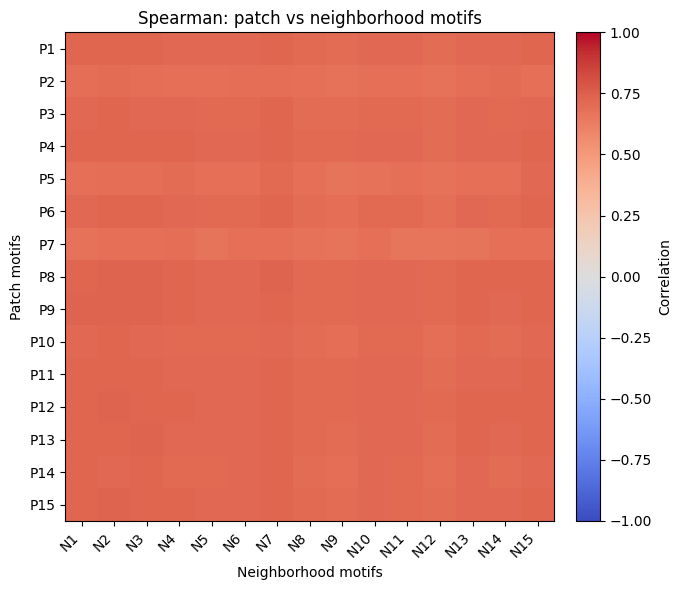

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from scipy.optimize import linear_sum_assignment

# ------------------------------------------------------------
# 已有：patch_array, neigh_array  # 形状都为 (15, N_LRI)
# ------------------------------------------------------------
A0, B0 = patch_array, neigh_array
assert A0.shape == B0.shape, "两个数组的形状必须一致（motif×LRI）"

# 0) 去掉在两套数据里都恒定的 LRI 列（如全0），避免相关性不定义
col_var = np.var(np.vstack([A0, B0]), axis=0)
mask = col_var > 0
A = A0[:, mask].astype(float)
B = B0[:, mask].astype(float)

# --- 工具函数 ---
def _pearson_rowcorr(A, B):
    """对每一对行（motif）求 Pearson；返回 15×15 矩阵"""
    n = A.shape[1]
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)
    sdA = A.std(axis=1, keepdims=True)
    sdB = B.std(axis=1, keepdims=True)
    sdA[sdA == 0] = np.nan
    sdB[sdB == 0] = np.nan
    ZA = A / sdA
    ZB = B / sdB
    C = np.nan_to_num(ZA @ ZB.T / n)   # z-score 后相关=均值(z1*z2)
    return C

def spearman_rowcorr(A, B):
    """对每行做秩变换，再做 Pearson -> Spearman"""
    RA = np.apply_along_axis(rankdata, 1, A)
    RB = np.apply_along_axis(rankdata, 1, B)
    return _pearson_rowcorr(RA, RB)

def plot_heatmap(M, title=""):
    fig, ax = plt.subplots(figsize=(6.8, 6))
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title or "Correlation heatmap")
    ax.set_xlabel("Neighborhood motifs")
    ax.set_ylabel("Patch motifs")
    ax.set_xticks(np.arange(M.shape[1]))
    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_xticklabels([f"N{j+1}" for j in range(M.shape[1])], rotation=45, ha="right")
    ax.set_yticklabels([f"P{i+1}" for i in range(M.shape[0])])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")
    plt.tight_layout()
    plt.show()

# 1) Spearman（推荐，对长尾/稀疏更稳）
C_s = spearman_rowcorr(A, B)
plot_heatmap(C_s, "Spearman: patch vs neighborhood motifs")

# 2) 可选：Pearson（原值）
# C_p = _pearson_rowcorr(A, B)
# plot_heatmap(C_p, "Pearson: patch vs neighborhood motifs")

# 2b) 可选：Pearson（log1p，更快，常作为敏感性检查）
# C_p_log = _pearson_rowcorr(np.log1p(A), np.log1p(B))
# plot_heatmap(C_p_log, "Pearson on log1p: patch vs neighborhood")

# 3) 可选：把列重排为“最佳一一对应”（让热图更接近对角亮块）
row_ind, col_ind = linear_sum_assignment(-C_s)  # 最大化相关
C_s_ordered = C_s[np.ix_(row_ind, col_ind)]
# plot_heatmap(C_s_ordered, "Spearman (reordered for best 1–1 match)")


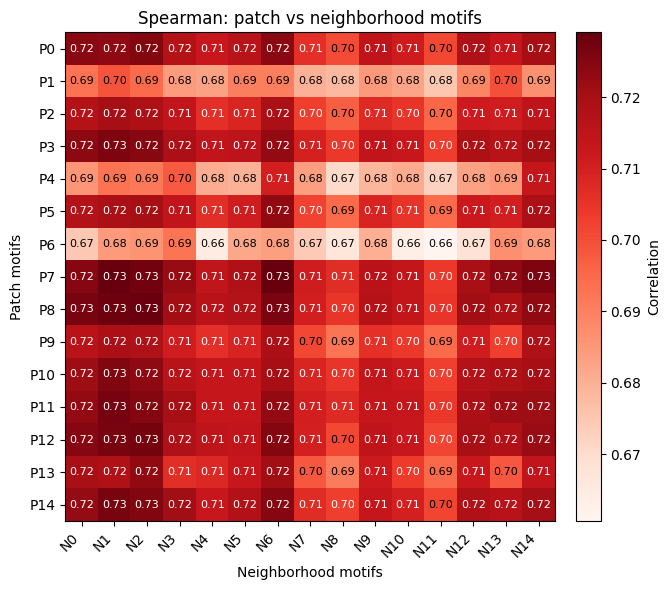

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_minmax(M, title="", xticklabels=None, yticklabels=None,
                        annotate=True, fmt="{:.2f}", text_threshold=0.6,
                        fontsize=8):
    """
    annotate: 是否在格子中打印数值
    fmt:      数值格式，如 "{:.2f}"
    text_threshold: im.norm(val) 超过该阈值用白字，否则黑字
    fontsize: 标注字体大小
    """
    M = np.asarray(M, dtype=float)
    vmin = np.nanmin(M)
    vmax = np.nanmax(M)
    if vmin == vmax:  # 极端情况避免除以0
        vmax = vmin + 1e-12

    fig, ax = plt.subplots(figsize=(6.8, 6))
    im = ax.imshow(M, cmap="Reds", vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_title(title or "Correlation heatmap")
    ax.set_xlabel("Neighborhood motifs")
    ax.set_ylabel("Patch motifs")
    ax.set_xticks(np.arange(M.shape[1]))
    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_xticklabels(xticklabels or [f"N{j}" for j in range(M.shape[1])],
                       rotation=45, ha="right")
    ax.set_yticklabels(yticklabels or [f"P{i}" for i in range(M.shape[0])])

    # 在格子中打印相关系数
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]
                if np.isnan(val):
                    continue
                # 根据底色亮度选择文字颜色
                color = "white" if im.norm(val) > text_threshold else "black"
                ax.text(j, i, fmt.format(val), ha="center", va="center",
                        color=color, fontsize=fontsize)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")
    plt.tight_layout()
    plt.show()


plot_heatmap_minmax(C_s, "Spearman: patch vs neighborhood motifs")

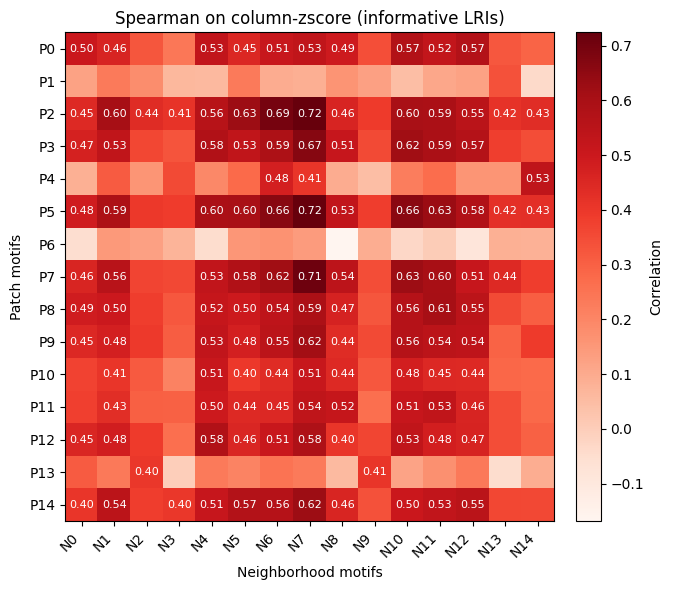

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# ---------- 工具 ----------
def select_union_topk(A, B, k=2000):
    """每个 motif 取各自的 Top-K LRI，最后取 A/B 的并集"""
    topA = np.argpartition(A, -k, axis=1)[:, -k:]
    topB = np.argpartition(B, -k, axis=1)[:, -k:]
    cols = np.unique(np.concatenate([topA.reshape(-1), topB.reshape(-1)]))
    return np.sort(cols)

def select_top_variance(A, B, pct=0.02):
    """按 A∪B 的列方差，取前 pct 的高方差列"""
    var = np.var(np.vstack([A, B]), axis=0)
    k = max(1, int(len(var) * pct))
    idx = np.argpartition(var, -k)[-k:]
    return np.sort(idx)

def column_zscore(A, B):
    X = np.vstack([A, B])
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True); sd[sd==0] = 1.0
    return (A - mu) / sd, (B - mu) / sd

def spearman_rowcorr(A, B):
    RA = np.apply_along_axis(rankdata, 1, A)
    RB = np.apply_along_axis(rankdata, 1, B)
    # Pearson on ranks
    RA -= RA.mean(axis=1, keepdims=True); RB -= RB.mean(axis=1, keepdims=True)
    denA = np.linalg.norm(RA, axis=1, keepdims=True); denA[denA==0]=1
    denB = np.linalg.norm(RB, axis=1, keepdims=True); denB[denB==0]=1
    return (RA @ RB.T) / (denA * denB.T)

def plot_heatmap_minmax(M, title="", annotate=True, fmt="{:.2f}", fs=8):
    vmin, vmax = np.nanmin(M), np.nanmax(M)
    if vmin == vmax: vmax = vmin + 1e-12
    fig, ax = plt.subplots(figsize=(6.8, 6))
    im = ax.imshow(M, cmap="Reds", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel("Neighborhood motifs"); ax.set_ylabel("Patch motifs")
    ax.set_xticks(np.arange(M.shape[1])); ax.set_yticks(np.arange(M.shape[0]))
    ax.set_xticklabels([f"N{j}" for j in range(M.shape[1])], rotation=45, ha="right")
    ax.set_yticklabels([f"P{i}" for i in range(M.shape[0])])
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]; 
                color = "white" if (val - vmin)/(vmax - vmin + 1e-12) > 0.6 else "black"
                if val>=0.4:
                    ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=fs, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Correlation")
    plt.tight_layout(); plt.show()

# ---------- 主流程（任选一种特征选择：Top-K 并集 或 高方差） ----------
# 假定已有 patch_array, neigh_array 形状 (15, 166035)
cols = select_union_topk(patch_array, neigh_array, k=2000)   # 或：select_top_variance(patch_array, neigh_array, pct=0.02)
A, B = patch_array[:, cols], neigh_array[:, cols]

# 列标准化（跨 A 和 B 一起 z-score），强调“相对基线的偏离”
A_z, B_z = column_zscore(A, B)

# Spearman（对稀疏和重尾更稳健）
C_s = spearman_rowcorr(A_z, B_z)
plot_heatmap_minmax(C_s, "Spearman on column-zscore (informative LRIs)")


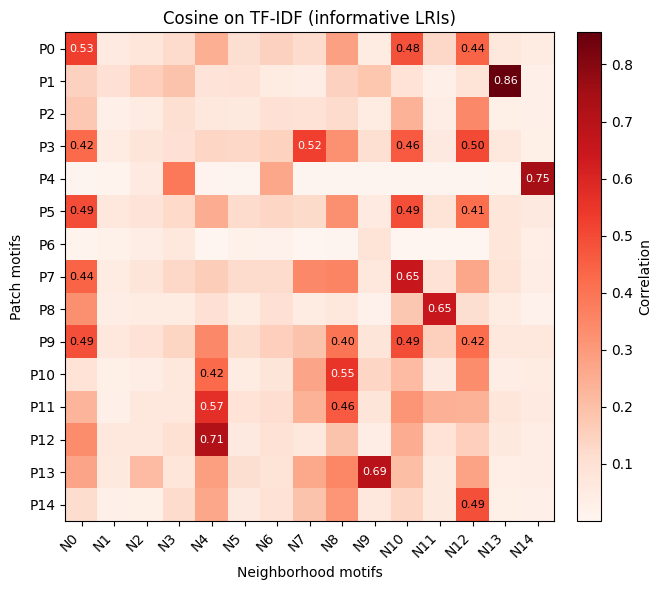

In [62]:
def tfidf_transform(A, B):
    # 统一的 IDF（基于 A∪B 的出现情况）
    df = ((A > 0) | (B > 0)).sum(axis=0)
    n_docs = A.shape[0] + B.shape[0]
    idf = np.log((1 + n_docs) / (1 + df)) + 1.0  # smooth IDF

    def apply(X):
        rs = X.sum(axis=1, keepdims=True); rs[rs==0] = 1.0
        tf = X / rs
        return tf * idf

    return apply(A), apply(B)

def row_cosine(A, B):
    denA = np.linalg.norm(A, axis=1, keepdims=True); denA[denA==0]=1
    denB = np.linalg.norm(B, axis=1, keepdims=True); denB[denB==0]=1
    return (A @ B.T) / (denA * denB.T)

# 仍建议先做特征选择（如上 cols）
A_tfidf, B_tfidf = tfidf_transform(A, B)
C_cos = row_cosine(A_tfidf, B_tfidf)
plot_heatmap_minmax(C_cos, "Cosine on TF-IDF (informative LRIs)", annotate=True)


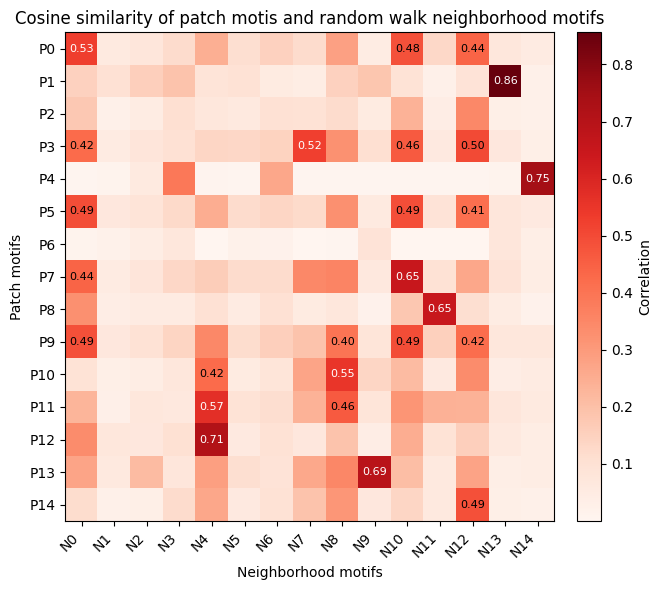

In [63]:
C_cos = row_cosine(A, B)
plot_heatmap_minmax(C_cos, "Cosine similarity of patch motis and random walk neighborhood motifs", annotate=True)

In [64]:
randomwalk = load_bptf_results('../results/ES_random_walk/bptf')
patch = load_bptf_results('../results/ES_cellphone_15/bptf')
patch_42 = load_bptf_results('../results/ES_cellphone_15/bptf_42')
patch_array, patch_array_42, neigh_array = patch['lri_factors'],patch_42['lri_factors'], randomwalk['lri_factors']

Loading BPTF results from: ../results/ES_random_walk/bptf
Loaded results:
  - Patch loadings: (78943, 15)
  - LRI factors: (15, 166035)
Loading BPTF results from: ../results/ES_cellphone_15/bptf
Loaded results:
  - Patch loadings: (90538, 15)
  - LRI factors: (15, 166035)
Loading BPTF results from: ../results/ES_cellphone_15/bptf_42
Loaded results:
  - Patch loadings: (90538, 15)
  - LRI factors: (15, 166035)


In [68]:
def plot_heatmap_minmax(M, title="", annotate=True, fmt="{:.2f}", fs=8):
    vmin, vmax = np.nanmin(M), np.nanmax(M)
    if vmin == vmax: vmax = vmin + 1e-12
    fig, ax = plt.subplots(figsize=(6.8, 6))
    im = ax.imshow(M, cmap="Reds", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel("Random walk neighborhood motifs"); ax.set_ylabel("Patch motifs (random_seed=42)")
    ax.set_xticks(np.arange(M.shape[1])); ax.set_yticks(np.arange(M.shape[0]))
    ax.set_xticklabels([f"motif {j}" for j in range(M.shape[1])], rotation=45, ha="right")
    ax.set_yticklabels([f"motif {i}" for i in range(M.shape[0])])
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]; 
                color = "white" if (val - vmin)/(vmax - vmin + 1e-12) > 0.6 else "black"
                if val>=0.4:
                    ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=fs, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Correlation")
    plt.tight_layout(); plt.show()

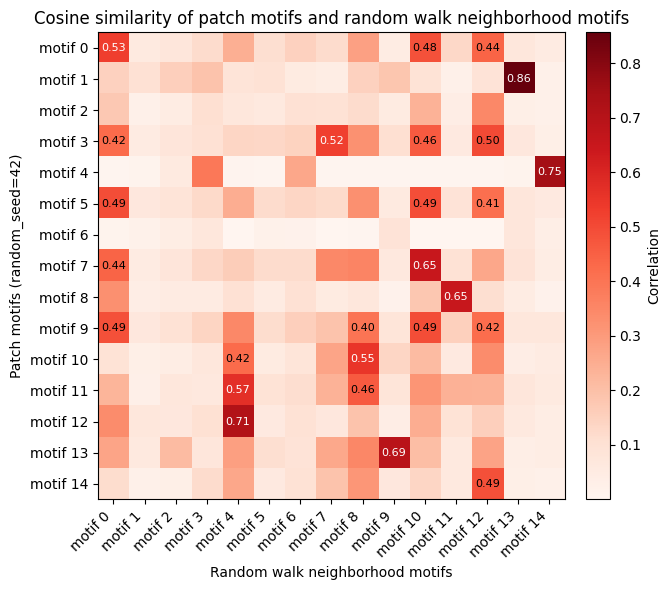

In [69]:
C_cos = row_cosine(patch_array_42, neigh_array)
plot_heatmap_minmax(C_cos, "Cosine similarity of patch motifs and random walk neighborhood motifs", annotate=True)

In [47]:
A_tfidf

array([[1.08664175e-11, 4.00093469e-06, 1.08664174e-11, ...,
        1.08908484e-11, 1.42289564e-11, 1.08665519e-11],
       [3.05184863e-11, 1.17781395e-05, 3.05188405e-11, ...,
        3.05614939e-11, 3.05368422e-11, 3.05199252e-11],
       [2.29028850e-11, 2.29062960e-11, 2.29026146e-11, ...,
        8.56942006e-07, 2.29232379e-11, 2.29030969e-11],
       ...,
       [4.01996745e-11, 3.81793858e-11, 3.79745187e-11, ...,
        2.28856713e-05, 3.44013706e-06, 3.82647310e-11],
       [1.84952333e-11, 1.85230759e-11, 1.84880969e-11, ...,
        1.85221872e-11, 1.88249533e-11, 1.84880405e-11],
       [1.64261689e-11, 1.00864756e-05, 1.64214163e-11, ...,
        1.65591859e-11, 1.64345292e-11, 1.64220637e-11]])

In [82]:
patch_assign = pd.read_csv('../results/ES_cellphone_15/cell_patch_correspondence.csv')
patch_assign['cell'] = patch_assign.index
patch_assign

,cell_id,patch_id,tma_id,cell_type,cell
0,aaaaaeej-1,87972,32.0,Tumor,0
1,aaaaannk-1,87972,32.0,Tumor,1
2,aaaabkff-1,87972,32.0,natural killer cell,2
3,aaaacbae-1,113900,31.0,Tumor,3
4,aaaadlmj-1,114824,31.0,muscle cell,4
...,...,...,...,...,...
1576156,oilklaje-1,115361,59.0,natural killer cell,1576156
1576157,oilkodcf-1,115361,59.0,macrophage,1576157
1576158,oilkpklo-1,115360,59.0,fibroblast,1576158
1576159,oillbmlp-1,115360,59.0,dendritic cell,1576159


In [71]:
neigh_assign = pd.read_csv('../results/ES_random_walk/20_cell_neighborhood_merged.csv')
neigh_assign

,cell,neighborhood_id
0,0,16955
1,1,19018
2,2,18266
3,3,60306
4,4,28433
...,...,...
1576156,1576156,69648
1576157,1576157,5258
1576158,1576158,7403
1576159,1576159,9950


In [72]:
neigh_assign[neigh_assign['neighborhood_id'] == 16955]

,cell,neighborhood_id
0,0,16955
22074,22074,16955
119300,119300,16955
211146,211146,16955
399263,399263,16955
582331,582331,16955
592049,592049,16955
785534,785534,16955
817967,817967,16955
879576,879576,16955


In [75]:
import scanpy as sc
adata = sc.read_h5ad('/Users/jiayifan/Desktop/Lab/epithelioid_spatial_new/data/processed/preprocessed_xenium_data_no_ctrl.h5ad')
adata.obs

,cell_id,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,...,cell_labels,tma_id,PARENT_TMA,cell_type,PATIENT_ID,PRIOR_Tazemetostat,CANCER_TYPE_DETAILED,SAMPLE_TYPE,n_counts,niche_labels
0,aaaaaeej-1,814,0,0,0,0,0,814,86.925784,56.851721,...,1,32.0,181550,Tumor,NaN,NaN,Proximal-Type Epithelioid Sarcoma,NaN,814.0,3.0
1,aaaaannk-1,693,0,0,0,0,0,693,71.211409,54.142346,...,2,32.0,181550,Tumor,NaN,NaN,Proximal-Type Epithelioid Sarcoma,NaN,693.0,3.0
2,aaaabkff-1,339,0,0,0,0,0,339,39.963283,36.350783,...,3,32.0,181550,natural killer cell,NaN,NaN,Proximal-Type Epithelioid Sarcoma,NaN,339.0,3.0
3,aaaacbae-1,507,0,0,0,0,0,507,39.602033,30.074064,...,4,31.0,181550,Tumor,NaN,NaN,Proximal-Type Epithelioid Sarcoma,NaN,507.0,3.0
4,aaaadlmj-1,794,0,0,0,0,0,794,83.268128,61.141565,...,5,31.0,181550,muscle cell,NaN,NaN,Proximal-Type Epithelioid Sarcoma,NaN,794.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576156,oilklaje-1,24,0,0,0,0,0,24,10.205313,8.670000,...,836306,59.0,181551,natural killer cell,P-0101150,0.0,Proximal-Type Epithelioid Sarcoma,locally recurrent,24.0,3.0
1576157,oilkodcf-1,71,0,0,0,0,0,71,34.860626,24.023126,...,836307,59.0,181551,macrophage,P-0101150,0.0,Proximal-Type Epithelioid Sarcoma,locally recurrent,71.0,3.0
1576158,oilkpklo-1,30,0,0,0,0,0,30,23.616720,20.365469,...,836308,59.0,181551,fibroblast,P-0101150,0.0,Proximal-Type Epithelioid Sarcoma,locally recurrent,30.0,3.0
1576159,oillbmlp-1,63,0,0,0,0,0,63,24.790782,21.494376,...,836309,59.0,181551,dendritic cell,P-0101150,0.0,Proximal-Type Epithelioid Sarcoma,locally recurrent,63.0,3.0


In [76]:
cellphone = pd.read_csv('../data/LRdatabase/CellPhoneDBv5.0.human.csv')
cellphone

,ligand,receptor,classification,directionality,id_cp_interaction,signaling_type
0,CDH1,ITGA2_ITGB1,Adhesion by Cadherin,Adhesion-Adhesion,CPI-SC0A2DB962D,Cell-Cell Contact
1,COL10A1,ITGA2_ITGB1,Adhesion by Collagen/Integrin,Adhesion-Adhesion,CPI-SC0B5CEA47D,Cell-Cell Contact
2,COL11A1,ITGA2_ITGB1,Adhesion by Collagen/Integrin,Adhesion-Adhesion,CPI-SC0C8B7BCBB,Cell-Cell Contact
3,COL11A2,ITGA2_ITGB1,Adhesion by Collagen/Integrin,Adhesion-Adhesion,CPI-SC0D3C12C3F,Cell-Cell Contact
4,COL12A1,ITGA2_ITGB1,Adhesion by Collagen/Integrin,Adhesion-Adhesion,CPI-SC0B86B7CED,Cell-Cell Contact
...,...,...,...,...,...,...
2906,SIGLEC15,CD44,NaN,Ligand-Receptor,CPI-SS07D508428,Secreted Signaling
2907,SPN,SIGLEC1,NaN,Ligand-Receptor,CPI-SS02A170A99,Cell-Cell Contact
2908,THPO,MPL,NaN,Ligand-Receptor,CPI-SS0DC2DD9D7,Secreted Signaling
2909,TRH,TRHR,NaN,Ligand-Receptor,CPI-SS00F69C501,Secreted Signaling


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2343216350.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(ct):


Neighborhood 19018: nodes=20, edges=289, LR rows used=202


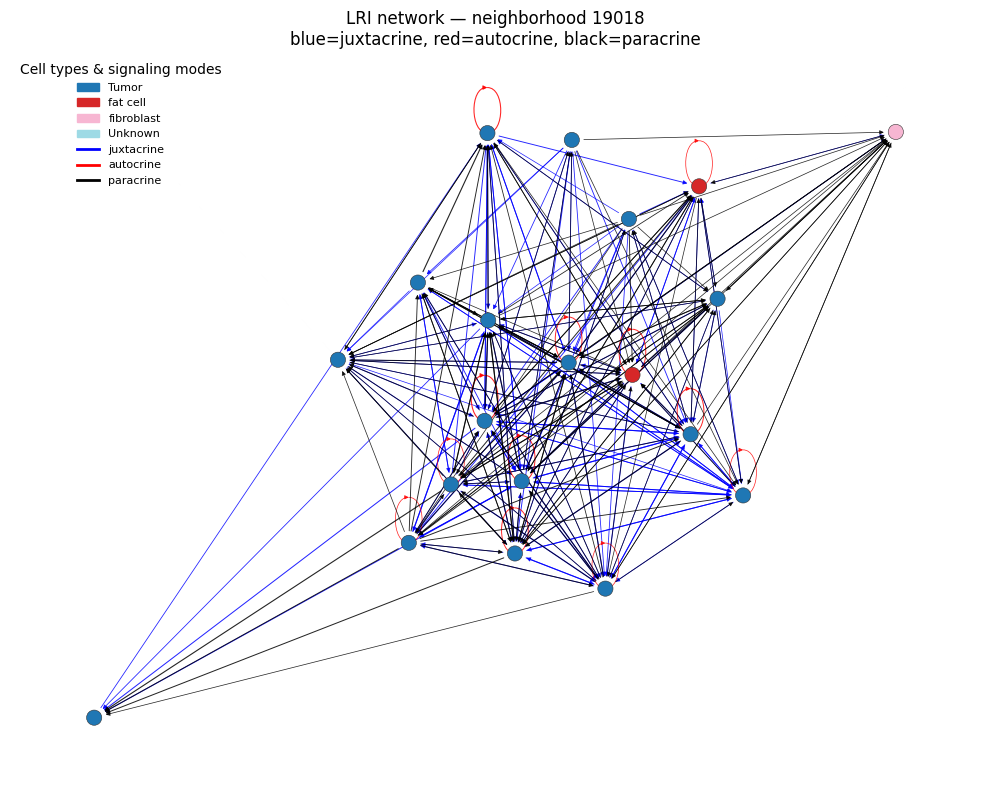

In [106]:
# ========== LRI NetworkX plot (juxtacrine/autocrine/paracrine) ==========

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

# ---------------- CONFIG ----------------
nh_id = 19018
expr_thr = 0.0
require_all_receptor_subunits = True
require_all_ligand_subunits = False

# drawing knobs
NODE_SIZE = 120          # <<< bigger dots (was 30)
NODE_EDGEWIDTH = 0.4
EDGE_BASE_WIDTH = 0.4
EDGE_SCALE = 0.12
EDGE_ALPHA = 0.85
LAYOUT_SEED = 42
SPRING_K = None          # None = let networkx choose; set e.g. 1.0 to spread more
# ---------------------------------------

# 0) inputs assumed present:
# neigh_assign: DataFrame with columns ['cell','neighborhood_id']
# adata: AnnData
# cellphone: DataFrame with columns ['ligand','receptor','signaling_type',...]

# ---------- helpers ----------
def case_insensitive_varmap(var_names: pd.Index) -> pd.Series:
    """Return mapping from UPPER gene -> original var_name (first occurrence)."""
    return pd.Series(var_names, index=[g.upper() for g in var_names]).groupby(level=0).first()

def map_present_genes(gene_str: str, var_upper: pd.Series) -> list[str]:
    """Split 'ITGA2_ITGB1' -> keep genes that exist in var_names (case-insensitive)."""
    out = []
    for g in str(gene_str).split("_"):
        gu = g.upper()
        if gu in var_upper.index:
            out.append(var_upper.loc[gu])
    return out

def cells_expressing(expr_df: pd.DataFrame, genes: list[str], thr: float, require_all: bool) -> pd.Index:
    if len(genes) == 0:
        return pd.Index([])
    sub = expr_df[genes]
    mask = (sub > thr).all(axis=1) if require_all else (sub > thr).any(axis=1)
    return expr_df.index[mask]

def get_cell_types(adata_sub) -> pd.Series:
    """Robustly fetch a cell_type Series with 'Unknown' filled."""
    if "cell_type" in adata_sub.obs:
        ct = adata_sub.obs["cell_type"].copy()
        if pd.api.types.is_categorical_dtype(ct):
            if "Unknown" not in ct.cat.categories:
                ct = ct.cat.add_categories(["Unknown"])
        ct = ct.fillna("Unknown")
    else:
        ct = pd.Series("Unknown", index=adata_sub.obs_names, dtype="object")
    return ct

def edge_width(weight: float) -> float:
    return EDGE_BASE_WIDTH + EDGE_SCALE * np.log2(1.0 + float(weight))
# ---------------------------------------

# 1) subset cells in neighborhood
nh_cells = (
    neigh_assign.loc[neigh_assign["neighborhood_id"] == nh_id, "cell"]
    .astype(str).values
)
adata_sub = adata[adata.obs_names.isin(nh_cells)]

# 2) prep expression
var_upper = case_insensitive_varmap(adata_sub.var_names)
X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
expr = pd.DataFrame(X, index=adata_sub.obs_names, columns=adata_sub.var_names)

# 3) colors for nodes (by cell_type)
cell_types = get_cell_types(adata_sub)
cats = pd.Categorical(cell_types)
palette = plt.get_cmap("tab20", len(cats.categories))
node_color_map = {ct: to_hex(palette(i)) for i, ct in enumerate(cats.categories)}
node_colors = [node_color_map[cell_types.loc[c]] for c in expr.index]

# 4) build the graph with edge modes
G = nx.DiGraph()
G.add_nodes_from(expr.index)

def add_edge(u, v, mode, ligand, receptor, signaling_type):
    if G.has_edge(u, v):
        G[u][v]["weight"] += 1
        G[u][v]["lris"].append((ligand, receptor, signaling_type, mode))
    else:
        G.add_edge(
            u, v,
            weight=1,
            mode=mode,
            lris=[(ligand, receptor, signaling_type, mode)],
        )

used_rows = 0
for _, row in cellphone.iterrows():
    lig = str(row["ligand"])
    rec = str(row["receptor"])
    st  = str(row.get("signaling_type", ""))  # "Cell-Cell Contact", "Secreted Signaling", ...

    lig_genes = map_present_genes(lig, var_upper)
    rec_genes = map_present_genes(rec, var_upper)
    if len(lig_genes) == 0 or len(rec_genes) == 0:
        continue

    lig_cells = cells_expressing(expr, lig_genes, expr_thr, require_all_ligand_subunits)
    rec_cells = cells_expressing(expr, rec_genes, expr_thr, require_all_receptor_subunits)
    if len(lig_cells) == 0 or len(rec_cells) == 0:
        continue

    used_rows += 1

    if st == "Cell-Cell Contact":
        # juxtacrine ONLY; skip same-cell case
        for u in lig_cells:
            for v in rec_cells:
                if u == v:
                    continue
                add_edge(u, v, mode="juxtacrine", ligand=lig, receptor=rec, signaling_type=st)
    else:
        # non-contact: autocrine (self) and paracrine (different cells)
        lig_set, rec_set = set(lig_cells), set(rec_cells)
        auto_cells = lig_set & rec_set

        for c in auto_cells:
            add_edge(c, c, mode="autocrine", ligand=lig, receptor=rec, signaling_type=st)

        for u in lig_set:
            for v in rec_set:
                if u == v:
                    continue
                add_edge(u, v, mode="paracrine", ligand=lig, receptor=rec, signaling_type=st)

print(f"Neighborhood {nh_id}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, LR rows used={used_rows}")

# 5) draw with NetworkX
edge_color_by_mode = {"juxtacrine": "blue", "autocrine": "red", "paracrine": "black"}

# layout (tweak SPRING_K to spread more; default ~ 1/sqrt(n))
pos = nx.spring_layout(G, seed=LAYOUT_SEED, k=SPRING_K)

plt.figure(figsize=(10, 8))

# nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=NODE_SIZE,
    node_color=node_colors,
    linewidths=NODE_EDGEWIDTH,
    edgecolors="#333333",
    alpha=1.0,
)

# edges grouped by mode so colors are clean
for mode, color in edge_color_by_mode.items():
    edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("mode") == mode]
    if not edgelist:
        continue
    widths = [edge_width(G[u][v]["weight"]) for u, v in edgelist]
    if mode == "autocrine":
        nx.draw_networkx_edges(
            G, pos, edgelist=edgelist,
            edge_color=color,
            width=widths,
            arrowsize=6,
            alpha=EDGE_ALPHA,
            connectionstyle="arc3,rad=0.25",  # make self-loops visible
        )
    else:
        nx.draw_networkx_edges(
            G, pos, edgelist=edgelist,
            edge_color=color,
            width=widths,
            arrowsize=6,
            alpha=EDGE_ALPHA,
        )

plt.title(f"LRI network — neighborhood {nh_id}\nblue=juxtacrine, red=autocrine, black=paracrine")
plt.axis("off")

# legends
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
node_legend_handles = [mpatches.Patch(color=col, label=ct) for ct, col in node_color_map.items()]
edge_legend_handles = [mlines.Line2D([], [], color=c, lw=2, label=m) for m, c in edge_color_by_mode.items()]

plt.legend(
    handles=node_legend_handles + edge_legend_handles,
    loc="best",
    fontsize=8,
    frameon=False,
    title="Cell types & signaling modes"
)

plt.tight_layout()
plt.show()
# =======================================================================


In [159]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

def plot_lri_network(
    cell_column: str,
    nbh_id_column: str,
    neigh_assign: pd.DataFrame,
    adata,                         # AnnData
    cellphone: pd.DataFrame,       # columns: ['ligand','receptor','signaling_type',...]
    nh_id,
    *,
    # expression / logic
    expr_thr: float = 0.0,
    require_all_receptor_subunits: bool = True,
    require_all_ligand_subunits: bool = False,
    # drawing knobs
    node_size: int = 120,
    node_edgewidth: float = 0.4,
    edge_base_width: float = 0.4,
    edge_scale: float = 0.12,
    edge_alpha: float = 0.85,
    layout_seed: int = 42,
    spring_k: float = None,          # set to e.g. 1.0 to spread more
    cmap_name: str = "tab20",
    figsize: tuple = (10, 8),
    plot: bool = True,
    verbose: bool = True,
):
    """
    Plot a cell-level LRI network for neighborhood `nh_id` using NetworkX.
    - Nodes = cells in the neighborhood (colored by adata.obs['cell_type'] if present)
    - Directed edges colored by signaling mode:
        juxtacrine (blue): Cell-Cell Contact; skip same-cell
        autocrine (red):   non-contact rows where ligand & receptor in same cell
        paracrine (black): non-contact rows between different cells
    Returns: (G, pos, node_color_map)
    """

    # ---------------- helpers ----------------
    def case_insensitive_varmap(var_names: pd.Index) -> pd.Series:
        return pd.Series(var_names, index=[g.upper() for g in var_names]).groupby(level=0).first()

    def map_present_genes(gene_str: str, var_upper: pd.Series) -> list[str]:
        out = []
        for g in str(gene_str).split("_"):
            gu = g.upper()
            if gu in var_upper.index:
                out.append(var_upper.loc[gu])
        return out

    def cells_expressing(expr_df: pd.DataFrame, genes: list[str], thr: float, require_all: bool) -> pd.Index:
        if len(genes) == 0:
            return pd.Index([])
        sub = expr_df[genes]
        mask = (sub > thr).all(axis=1) if require_all else (sub > thr).any(axis=1)
        return expr_df.index[mask]

    def get_cell_types(adata_sub) -> pd.Series:
        if "cell_type" in adata_sub.obs:
            ct = adata_sub.obs["cell_type"].copy()
            if pd.api.types.is_categorical_dtype(ct):
                if "Unknown" not in ct.cat.categories:
                    ct = ct.cat.add_categories(["Unknown"])
            ct = ct.fillna("Unknown")
        else:
            ct = pd.Series("Unknown", index=adata_sub.obs_names, dtype="object")
        return ct

    def edge_width(weight: float) -> float:
        return edge_base_width + edge_scale * np.log2(1.0 + float(weight))
    # -----------------------------------------

    # 1) subset cells in the requested neighborhood
    nh_cells = (
        neigh_assign.loc[neigh_assign[nbh_id_column] == nh_id, cell_column]
        .astype(str).values
    )
    adata_sub = adata[adata.obs_names.isin(nh_cells)]

    # 2) prep expression
    var_upper = case_insensitive_varmap(adata_sub.var_names)
    X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
    expr = pd.DataFrame(X, index=adata_sub.obs_names, columns=adata_sub.var_names)

    # 3) colors for nodes (by cell_type)
    # Make sure cell_type is categorical
    if not pd.api.types.is_categorical_dtype(adata.obs["cell_type"]):
        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

    # Get all categories (fixed order)
    cats = adata.obs["cell_type"].cat.categories

    # Assign each category a fixed tab20 color
    palette = plt.get_cmap("tab20", len(cats))
    cell_type_color_map = {ct: to_hex(palette(i)) for i, ct in enumerate(cats)}

    # Store this globally so it stays consistent across all plotting
    adata.uns["cell_type_colors"] = cell_type_color_map
    
    cell_types = get_cell_types(adata_sub)
    cell_type_color_map = adata.uns.get("cell_type_colors", None)

    if cell_type_color_map is None:
        # fallback: build it once if not found
        cats = pd.Categorical(cell_types)
        palette = plt.get_cmap("tab20", len(cats.categories))
        cell_type_color_map = {ct: to_hex(palette(i)) for i, ct in enumerate(cats.categories)}

    node_colors = [cell_type_color_map.get(cell_types.loc[c], "#cccccc") for c in expr.index]

    # 4) build the graph with edge modes
    G = nx.DiGraph()
    G.add_nodes_from(expr.index)

    def add_edge(u, v, mode, ligand, receptor, signaling_type):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
            G[u][v]["lris"].append((ligand, receptor, signaling_type, mode))
        else:
            G.add_edge(
                u, v,
                weight=1,
                mode=mode,
                lris=[(ligand, receptor, signaling_type, mode)],
            )

    used_rows = 0
    for _, row in cellphone.iterrows():
        lig = str(row["ligand"])
        rec = str(row["receptor"])
        st  = str(row.get("signaling_type", ""))  # "Cell-Cell Contact", "Secreted Signaling", ...

        lig_genes = map_present_genes(lig, var_upper)
        rec_genes = map_present_genes(rec, var_upper)
        if len(lig_genes) == 0 or len(rec_genes) == 0:
            continue

        lig_cells = cells_expressing(expr, lig_genes, expr_thr, require_all_ligand_subunits)
        rec_cells = cells_expressing(expr, rec_genes, expr_thr, require_all_receptor_subunits)
        if len(lig_cells) == 0 or len(rec_cells) == 0:
            continue

        used_rows += 1

        if st == "Cell-Cell Contact":
            # juxtacrine ONLY; skip same-cell case
            for u in lig_cells:
                for v in rec_cells:
                    if u == v:
                        continue
                    add_edge(u, v, mode="juxtacrine", ligand=lig, receptor=rec, signaling_type=st)
        else:
            # non-contact: autocrine (self) and paracrine (different cells)
            lig_set, rec_set = set(lig_cells), set(rec_cells)
            auto_cells = lig_set & rec_set

            for c in auto_cells:
                add_edge(c, c, mode="autocrine", ligand=lig, receptor=rec, signaling_type=st)

            for u in lig_set:
                for v in rec_set:
                    if u == v:
                        continue
                    add_edge(u, v, mode="paracrine", ligand=lig, receptor=rec, signaling_type=st)

    if verbose:
        print(f"Neighborhood {nh_id}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, LR rows used={used_rows}")

    if plot == False:
        return G, None, cell_type_color_map
    # 5) draw with NetworkX
    edge_color_by_mode = {"juxtacrine": "blue", "autocrine": "red", "paracrine": "black"}

    pos = nx.spring_layout(G, seed=layout_seed, k=spring_k)

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=node_colors,
        linewidths=node_edgewidth,
        edgecolors="#333333",
        alpha=1.0,
    )

    for mode, color in edge_color_by_mode.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("mode") == mode]
        if not edgelist:
            continue
        widths = [edge_width(G[u][v]["weight"]) for u, v in edgelist]
        if mode == "autocrine":
            nx.draw_networkx_edges(
                G, pos, edgelist=edgelist,
                edge_color=color,
                width=widths,
                arrowsize=6,
                alpha=edge_alpha,
                connectionstyle="arc3,rad=0.25",
            )
        else:
            nx.draw_networkx_edges(
                G, pos, edgelist=edgelist,
                edge_color=color,
                width=widths,
                arrowsize=6,
                alpha=edge_alpha,
            )

    plt.title(f"LRI network — {nbh_id_column} {nh_id}")
    plt.axis("off")

    # legends
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    node_legend_handles = [mpatches.Patch(color=col, label=ct) for ct, col in node_color_map.items()]
    edge_legend_handles = [mlines.Line2D([], [], color=c, lw=2, label=m) for m, c in edge_color_by_mode.items()]

    plt.legend(
        handles=node_legend_handles + edge_legend_handles,
        loc="best",
        fontsize=8,
        frameon=False,
        title="Cell types & signaling modes"
    )
    plt.tight_layout()
    plt.show()

    return G, pos, node_color_map


In [146]:
def graph_connectivity_summary(G):
    G_und = G.to_undirected()
    n_nodes, n_edges = G.number_of_nodes(), G.number_of_edges()
    n_comp = nx.number_connected_components(G_und)
    largest_cc = max(nx.connected_components(G_und), key=len)
    frac_giant = len(largest_cc) / n_nodes
    avg_deg = np.mean([d for _, d in G.degree()])
    dens = nx.density(G)
    cluster = nx.average_clustering(G_und)
    return {
        "nodes": n_nodes,
        "edges": n_edges,
        "components": n_comp,
        "frac_giant_component": frac_giant,
        "avg_degree": avg_deg,
        "density": dens,
        "clustering": cluster
    }

In [163]:
import numpy as np
import pandas as pd
import warnings
from tqdm import tqdm

summaries = []

ids = patch_assign['patch_id'].unique()
print(f"Total patches: {len(ids)}")
samples = np.random.choice(ids, size=200, replace=False)

# tqdm 自动显示进度条
for i in tqdm(samples, desc="Processing patches", ncols=80):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # 暂时屏蔽所有警告

        G, _, _ = plot_lri_network(
            cell_column='cell',
            nbh_id_column='patch_id',
            neigh_assign=patch_assign,
            adata=adata,
            cellphone=cellphone,
            nh_id=i,
            plot=False,
            verbose=False
        )

        summary = graph_connectivity_summary(G)
        summary["nb_id"] = i
        summaries.append(summary)



df_summary = pd.DataFrame(summaries)

df_summary = df_summary[["nb_id"] + [c for c in df_summary.columns if c != "nb_id"]]

df_summary.head()

Total patches: 90538


Processing patches:   0%|                               | 0/200 [00:00<?, ?it/s]

Processing patches: 100%|█████████████████████| 200/200 [02:43<00:00,  1.22it/s]


,nb_id,nodes,edges,components,frac_giant_component,avg_degree,density,clustering
0,13673,18,317,1,1.000000,35.222222,1.035948,1.000000
1,186179,29,182,1,1.000000,12.551724,0.224138,0.647608
2,14837,7,30,1,1.000000,8.571429,0.714286,0.876190
3,113683,12,135,1,1.000000,22.500000,1.022727,1.000000
4,10195,3,2,2,0.666667,1.333333,0.333333,0.000000


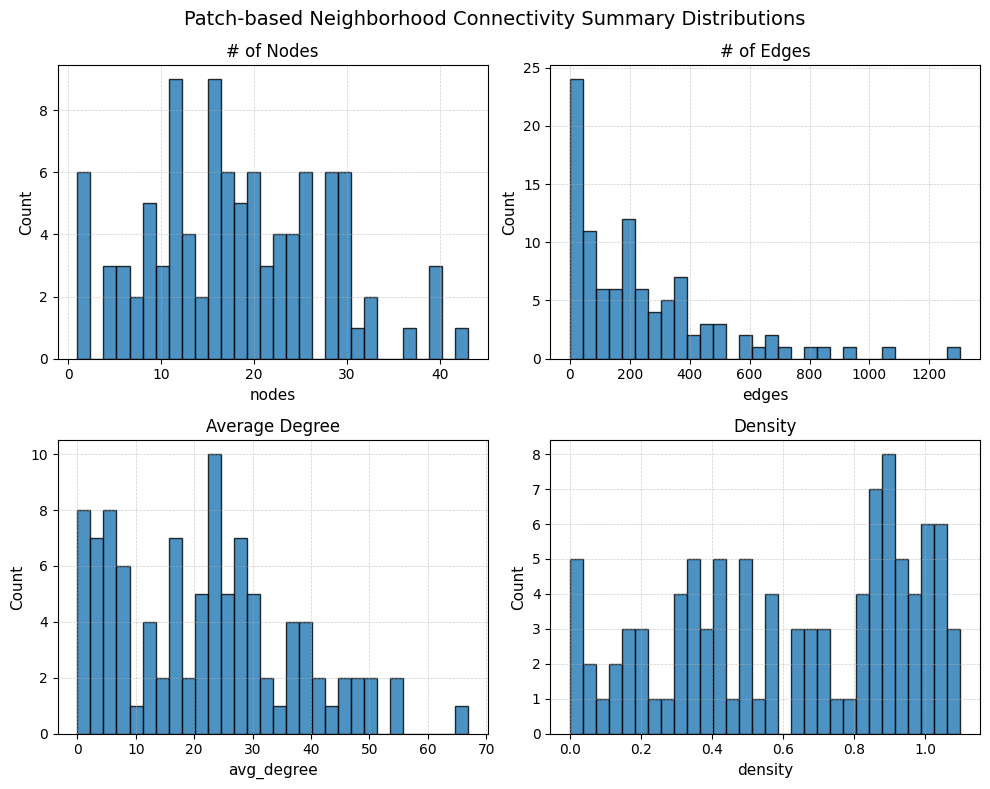

In [156]:
import numpy as np
import matplotlib.pyplot as plt

cols = ["nodes", "edges", "avg_degree", "density"]
titles = ["# of Nodes", "# of Edges", "Average Degree", "Density"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    x = df_summary[col].dropna().values
    ax.hist(x, bins=30, edgecolor="k", alpha=0.8)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

fig.suptitle("Patch-based Neighborhood Connectivity Summary Distributions", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


In [164]:
import numpy as np
import pandas as pd
import warnings
from tqdm import tqdm

summaries = []

ids = neigh_assign['neighborhood_id'].unique()
print(f"Total neighborhoods: {len(ids)}")
samples = np.random.choice(ids, size=200, replace=False)

# tqdm 自动显示进度条
for i in tqdm(samples, desc="Processing patches", ncols=80):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # 暂时屏蔽所有警告

        G, _, _ = plot_lri_network(
            cell_column='cell',
            nbh_id_column='neighborhood_id',
            neigh_assign=neigh_assign,
            adata=adata,
            cellphone=cellphone,
            nh_id=i,
            plot=False,
            verbose=False
        )

        summary = graph_connectivity_summary(G)
        summary["nb_id"] = i
        summaries.append(summary)



df_summary_rw = pd.DataFrame(summaries)

df_summary_rw = df_summary_rw[["nb_id"] + [c for c in df_summary_rw.columns if c != "nb_id"]]

df_summary_rw.head()

Total neighborhoods: 78943


Processing patches: 100%|█████████████████████| 200/200 [02:45<00:00,  1.21it/s]


,nb_id,nodes,edges,components,frac_giant_component,avg_degree,density,clustering
0,29939,20,297,1,1.0,29.7,0.781579,0.910490
1,44818,20,235,1,1.0,23.5,0.618421,0.844754
2,36523,20,272,1,1.0,27.2,0.715789,0.897341
3,51615,20,197,1,1.0,19.7,0.518421,0.804637
4,22800,20,332,1,1.0,33.2,0.873684,0.961803


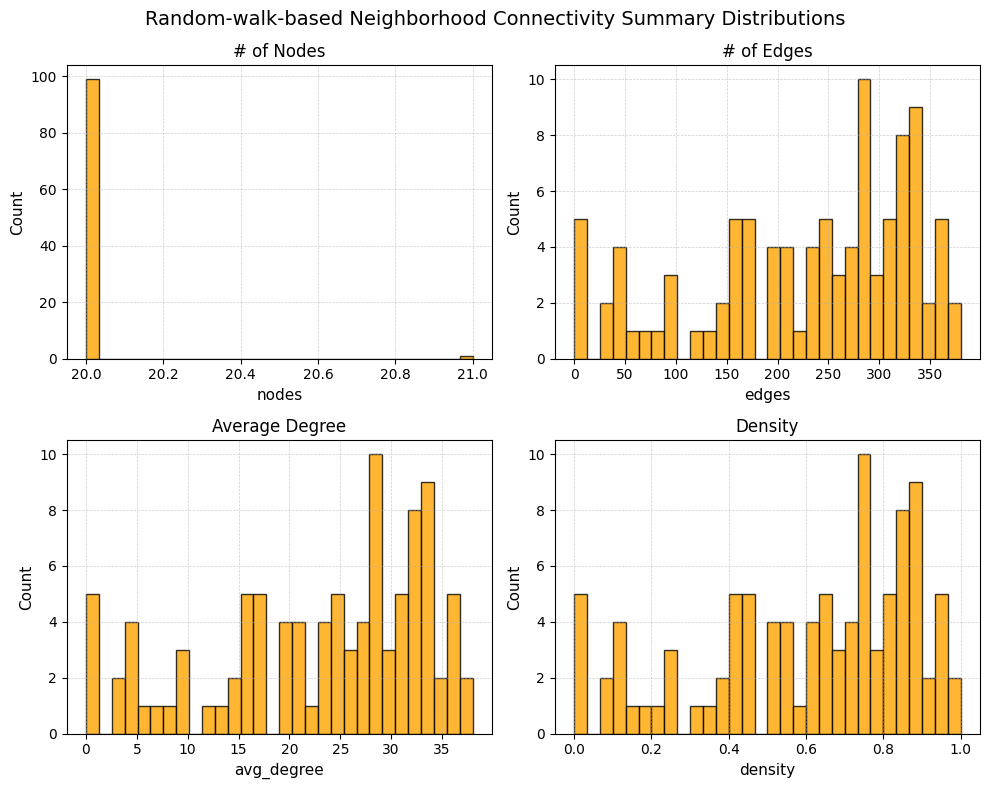

In [161]:
import numpy as np
import matplotlib.pyplot as plt

cols = ["nodes", "edges", "avg_degree", "density"]
titles = ["# of Nodes", "# of Edges", "Average Degree", "Density"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    x = df_summary_rw[col].dropna().values
    ax.hist(x, bins=30, edgecolor="k", alpha=0.8, color='orange')
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

fig.suptitle("Random-walk-based Neighborhood Connectivity Summary Distributions", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


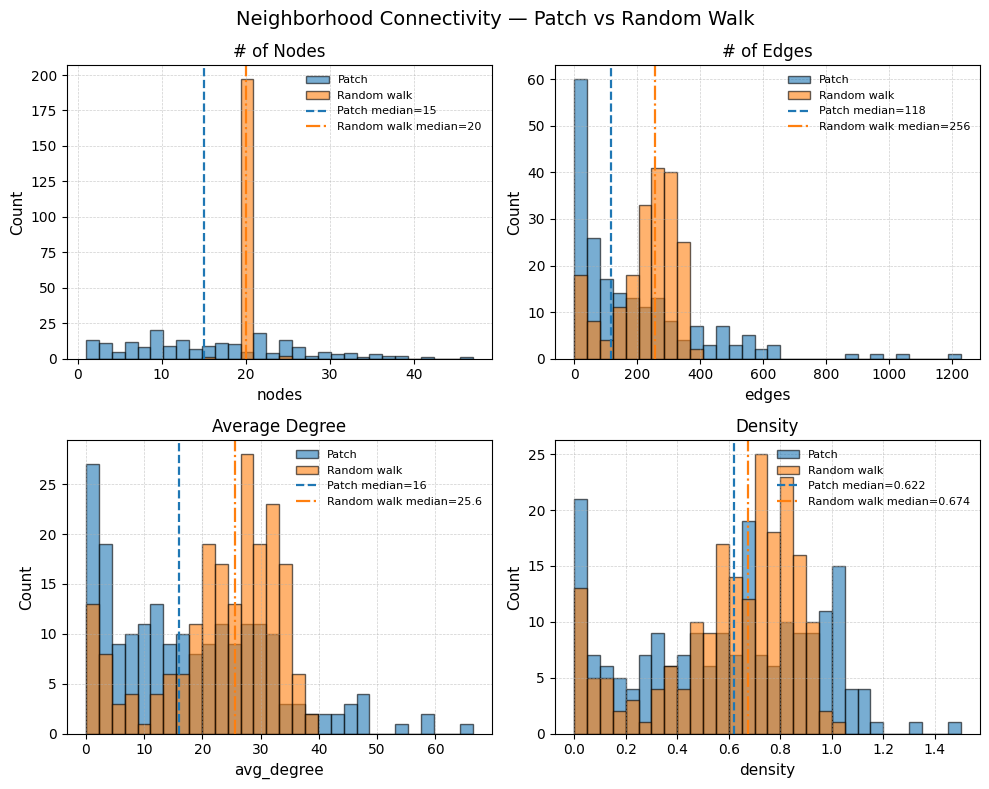

In [165]:
import numpy as np
import matplotlib.pyplot as plt

# columns to compare
cols   = ["nodes", "edges", "avg_degree", "density"]
titles = ["# of Nodes", "# of Edges", "Average Degree", "Density"]

# colors & labels
c1, c2 = "tab:blue", "tab:orange"
lab1, lab2 = "Patch", "Random walk"

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    x1 = df_summary[col].dropna().values
    x2 = df_summary_rw[col].dropna().values

    # shared bins (same x-scale for both)
    if x1.size and x2.size:
        xmin = min(x1.min(), x2.min())
        xmax = max(x1.max(), x2.max())
    else:  # handle empty edge cases
        xmin = x1.min() if x1.size else x2.min()
        xmax = x1.max() if x1.size else x2.max()
    edges = np.linspace(xmin, xmax, 31)  # 30 bins, shared

    # overlay histograms
    ax.hist(x1, bins=edges, edgecolor="k", alpha=0.6, color=c1, label=lab1)
    ax.hist(x2, bins=edges, edgecolor="k", alpha=0.6, color=c2, label=lab2)

    # medians
    if x1.size:
        m1 = np.median(x1)
        ax.axvline(m1, color=c1, linestyle="--", linewidth=1.6, label=f"{lab1} median={m1:.3g}")
    if x2.size:
        m2 = np.median(x2)
        ax.axvline(m2, color=c2, linestyle="-.", linewidth=1.6, label=f"{lab2} median={m2:.3g}")

    # labels, grid, title
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # ensure both groups visible in legend without duplicates
    handles, labels = ax.get_legend_handles_labels()
    # keep first unique label only
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), fontsize=8, frameon=False)

fig.suptitle("Neighborhood Connectivity — Patch vs Random Walk", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2832479345.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2832479345.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2832479345.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2832479345.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

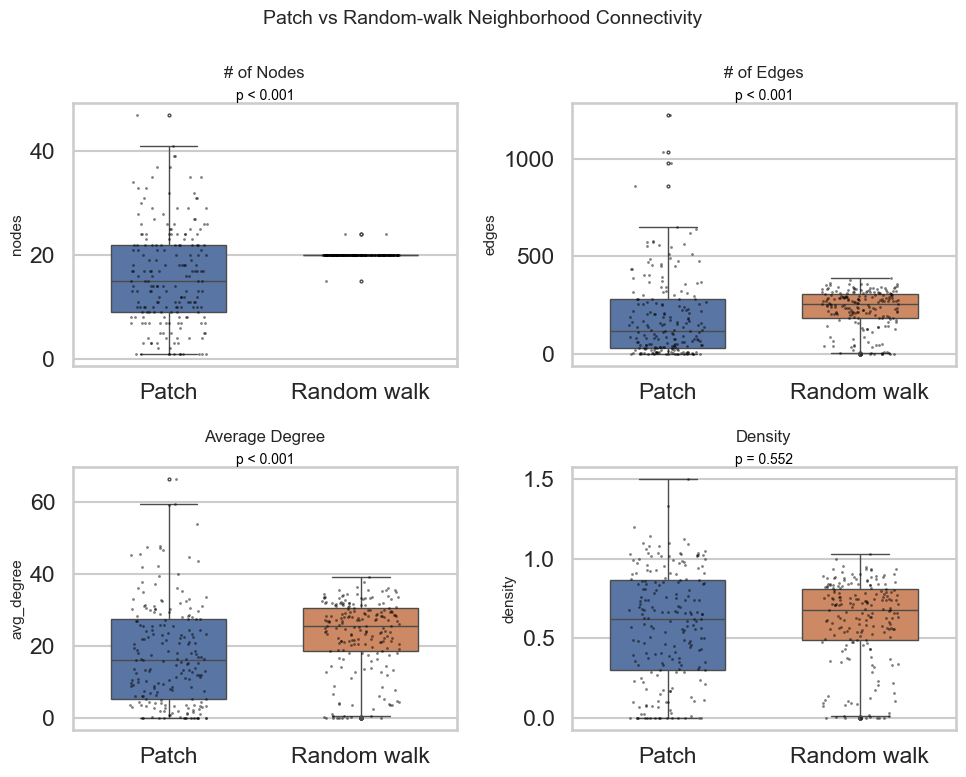

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import pandas as pd

cols   = ["nodes", "edges", "avg_degree", "density"]
titles = ["# of Nodes", "# of Edges", "Average Degree", "Density"]

df_patch = df_summary.assign(group="Patch")
df_rw    = df_summary_rw.assign(group="Random walk")
df_all   = pd.concat([df_patch, df_rw], ignore_index=True)

def add_pval(ax, data, y, group_col="group"):
    groups = data[group_col].unique()
    if len(groups) != 2:
        return
    g1, g2 = groups
    x1 = data.loc[data[group_col] == g1, y].dropna()
    x2 = data.loc[data[group_col] == g2, y].dropna()
    if len(x1) == 0 or len(x2) == 0:
        return
    stat, p = stats.mannwhitneyu(x1, x2, alternative="two-sided")
    p_text = "p < 0.001" if p < 1e-3 else f"p = {p:.3f}"

    # place label slightly above the upper whisker
    y_max = max(data[y].max(), np.percentile(data[y], 95))
    ax.text(0.5, y_max * 1.05, p_text,
            ha="center", va="bottom", fontsize=10, color="black")

sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    sns.boxplot(
        data=df_all, x="group", y=col,
        ax=ax, palette=["#4c72b0", "#dd8452"],
        width=0.6, fliersize=2
    )
    sns.stripplot(
        data=df_all, x="group", y=col,
        ax=ax, color="black", size=2, jitter=0.2, alpha=0.5
    )
    add_pval(ax, df_all, col)
    ax.set_title(title, fontsize=12, pad=18)  # pad adds vertical spacing
    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=11)

fig.suptitle("Patch vs Random-walk Neighborhood Connectivity", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/3009497989.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


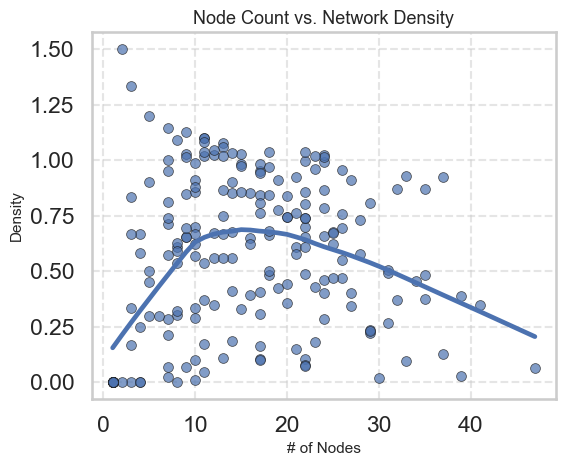

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine summaries
df_patch = df_summary.assign(group="Patch")
df_rw    = df_summary_rw.assign(group="Random walk")
df_all   = pd.concat([df_patch, df_rw], ignore_index=True)

# Scatter: nodes vs density
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df_patch,
    x="nodes", y="density",
    palette=["#4c72b0", "#dd8452"],
    alpha=0.7, edgecolor="k", s=50
)

# Optional trend lines
sns.regplot(
    data=df_patch, x="nodes", y="density",
    scatter=False, color="#4c72b0", lowess=True, label="Regression line"
)

plt.title("Node Count vs. Network Density", fontsize=13)
plt.xlabel("# of Nodes", fontsize=11)
plt.ylabel("Density", fontsize=11)
# plt.legend(title="Neighborhood type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


/Users/jiayifan/anaconda3/envs/tf2.10/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


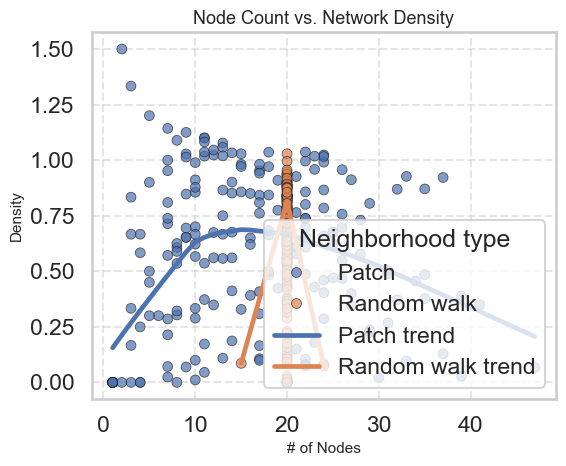

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine summaries
df_patch = df_summary.assign(group="Patch")
df_rw    = df_summary_rw.assign(group="Random walk")
df_all   = pd.concat([df_patch, df_rw], ignore_index=True)

# Scatter: nodes vs density
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df_all,
    x="nodes", y="density",
    hue="group", palette=["#4c72b0", "#dd8452"],
    alpha=0.7, edgecolor="k", s=50
)

# Optional trend lines
sns.regplot(
    data=df_patch, x="nodes", y="density",
    scatter=False, color="#4c72b0", lowess=True, label="Patch trend"
)
sns.regplot(
    data=df_rw, x="nodes", y="density",
    scatter=False, color="#dd8452", lowess=True, label="Random walk trend"
)

plt.title("Node Count vs. Network Density", fontsize=13)
plt.xlabel("# of Nodes", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.legend(title="Neighborhood type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [186]:
patch_assign

,cell_id,patch_id,tma_id,cell_type,cell
0,aaaaaeej-1,87972,32.0,Tumor,0
1,aaaaannk-1,87972,32.0,Tumor,1
2,aaaabkff-1,87972,32.0,natural killer cell,2
3,aaaacbae-1,113900,31.0,Tumor,3
4,aaaadlmj-1,114824,31.0,muscle cell,4
...,...,...,...,...,...
1576156,oilklaje-1,115361,59.0,natural killer cell,1576156
1576157,oilkodcf-1,115361,59.0,macrophage,1576157
1576158,oilkpklo-1,115360,59.0,fibroblast,1576158
1576159,oillbmlp-1,115360,59.0,dendritic cell,1576159


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/238174953.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ct, x="method", y="n_unique_celltypes", palette=["#4c72b0", "#dd8452"])


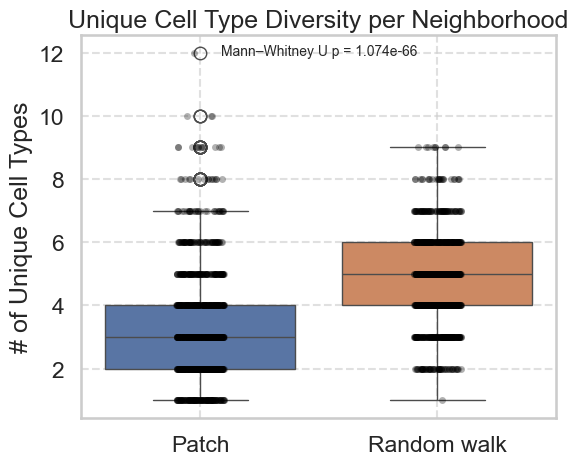

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Randomly sample 200 neighborhoods from each
sample_patch = np.random.choice(patch_assign['patch_id'].unique(), size=1000, replace=False)
sample_rw = np.random.choice(neigh_assign['neighborhood_id'].unique(), size=1000, replace=False)

def count_unique_celltypes(assign_df, adata, id_col, cell_col):
    """Return dataframe of nb_id and unique cell_type count per neighborhood."""
    results = []
    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]
        if "cell_type" in sub.columns:
            n_types = sub["cell_type"].nunique()
        else:
            n_types = np.nan
        results.append({"nb_id": nb_id, "n_unique_celltypes": n_types})
    return pd.DataFrame(results)

# Compute for sampled neighborhoods
df_patch_ct = count_unique_celltypes(patch_assign[patch_assign['patch_id'].isin(sample_patch)],
                                     adata, 'patch_id', 'cell')
df_rw_ct = count_unique_celltypes(neigh_assign[neigh_assign['neighborhood_id'].isin(sample_rw)],
                                  adata, 'neighborhood_id', 'cell')

# Label and concatenate
df_patch_ct["method"] = "Patch"
df_rw_ct["method"] = "Random walk"
df_ct = pd.concat([df_patch_ct, df_rw_ct], ignore_index=True)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_ct, x="method", y="n_unique_celltypes", palette=["#4c72b0", "#dd8452"])
sns.stripplot(data=df_ct, x="method", y="n_unique_celltypes", color="black", alpha=0.3, jitter=True)

plt.title("Unique Cell Type Diversity per Neighborhood")
plt.xlabel("")
plt.ylabel("# of Unique Cell Types")
plt.grid(True, linestyle="--", alpha=0.6)

# Optionally add p-value
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(df_patch_ct["n_unique_celltypes"], df_rw_ct["n_unique_celltypes"], alternative="two-sided")
plt.text(0.5, plt.ylim()[1]*0.95, f"Mann–Whitney U p = {pval:.3e}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


Sampled 994 patches and 992 random-walk neighborhoods.


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/4076261992.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ct, x="method", y="n_unique_celltypes", palette=["#4c72b0", "#dd8452"])


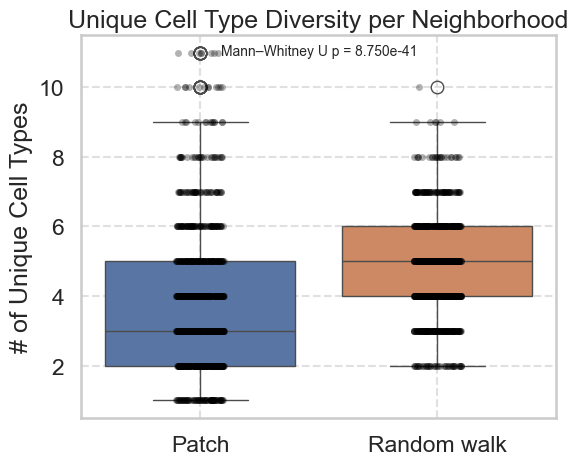

In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Randomly sample 200 neighborhoods from each
sample_patch = np.random.choice(patch_assign['patch_id'], size=1000, replace=False)
sample_rw = np.random.choice(neigh_assign['neighborhood_id'], size=1000, replace=False)
sample_patch = np.unique(sample_patch)
sample_rw = np.unique(sample_rw)
print(f"Sampled {len(sample_patch)} patches and {len(sample_rw)} random-walk neighborhoods.")

def count_unique_celltypes(assign_df, adata, id_col, cell_col):
    """Return dataframe of nb_id and unique cell_type count per neighborhood."""
    results = []
    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]
        if "cell_type" in sub.columns:
            n_types = sub["cell_type"].nunique()
        else:
            n_types = np.nan
        results.append({"nb_id": nb_id, "n_unique_celltypes": n_types})
    return pd.DataFrame(results)

# Compute for sampled neighborhoods
df_patch_ct = count_unique_celltypes(patch_assign[patch_assign['patch_id'].isin(sample_patch)],
                                     adata, 'patch_id', 'cell')
df_rw_ct = count_unique_celltypes(neigh_assign[neigh_assign['neighborhood_id'].isin(sample_rw)],
                                  adata, 'neighborhood_id', 'cell')

# Label and concatenate
df_patch_ct["method"] = "Patch"
df_rw_ct["method"] = "Random walk"
df_ct = pd.concat([df_patch_ct, df_rw_ct], ignore_index=True)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_ct, x="method", y="n_unique_celltypes", palette=["#4c72b0", "#dd8452"])
sns.stripplot(data=df_ct, x="method", y="n_unique_celltypes", color="black", alpha=0.3, jitter=True)

plt.title("Unique Cell Type Diversity per Neighborhood")
plt.xlabel("")
plt.ylabel("# of Unique Cell Types")
plt.grid(True, linestyle="--", alpha=0.6)

# Optionally add p-value
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(df_patch_ct["n_unique_celltypes"], df_rw_ct["n_unique_celltypes"], alternative="two-sided")
plt.text(0.5, plt.ylim()[1]*0.95, f"Mann–Whitney U p = {pval:.3e}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


In [193]:
nb_cells = patch_assign.loc[patch_assign['patch_id'] == 87972, 'cell'].astype(str)
print(nb_cells)
sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]
print(sub['cell_type'])

0              0
1              1
2              2
8              8
406160    406160
406161    406161
406162    406162
406171    406171
406172    406172
406173    406173
406177    406177
406212    406212
406213    406213
406214    406214
406215    406215
406216    406216
406217    406217
406218    406218
406227    406227
406228    406228
406365    406365
406368    406368
406393    406393
Name: cell, dtype: object
0                       Tumor
1                       Tumor
2         natural killer cell
8                       Tumor
406160                  Tumor
406161                  Tumor
406162                  Tumor
406171                  Tumor
406172                  Tumor
406173                  Tumor
406177                  Tumor
406212                  Tumor
406213             fibroblast
406214                  Tumor
406215                  Tumor
406216               fat cell
406217             macrophage
406218                  Tumor
406227                  Tumor
406228       

In [192]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '1576151', '1576152', '1576153', '1576154', '1576155', '1576156',
       '1576157', '1576158', '1576159', '1576160'],
      dtype='object', length=1576161)

In [189]:
sample_patch

array([158901, 151116,  92724, 114598,  14496,  19274, 128449, 171877,
       137544, 151983, 129000, 130126,  18547, 187568, 163834,  41979,
        90368,  93527, 171261, 185171, 136941, 137803,  74377,  15483,
       122058,  28004,  22274, 130152, 127686,  80259, 114724,  84064,
       121198,  40526, 117888, 186585, 189251, 188734, 168896,  73428,
        80863, 184837, 154767,  13613,  10724, 138856,  54305, 128364,
       190455, 188394, 181613,  35274, 100310, 145747,  96649,  39458,
       166415,  20531,  17433,  73004,  75395,  44279, 186878,  26802,
        84974, 197983, 191425, 175786,  66160,  42385, 185720, 137104,
       189072, 141604,  30182, 149021,  35907,  98514,  77881,  67761,
        68811, 185874,  46471,  23899, 133410, 170124, 192247, 107354,
        66492, 160207, 139723,   5345,  93878,  80341,  27809, 184335,
        57521,  70858,  66094,  39946,  18619,  34056,  94801, 181970,
       121025,  82698, 136988, 165688,  26158, 123346,  62336,  85565,
      

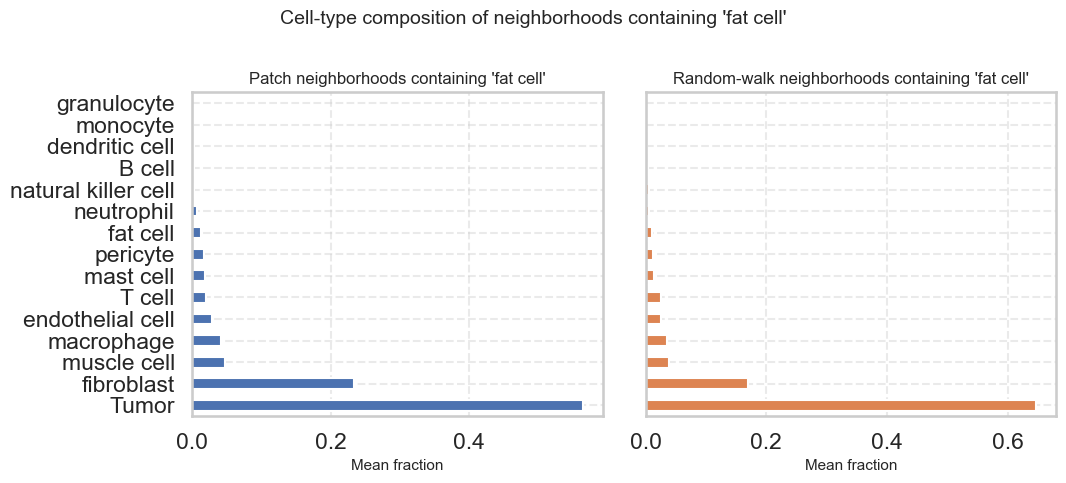

In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
target_celltype = "fat cell"
n_sample = 200
# ----------------------------------------

# Randomly sample neighborhoods
sample_patch = np.random.choice(patch_assign['patch_id'].unique(), size=n_sample, replace=False)
sample_rw = np.random.choice(neigh_assign['neighborhood_id'].unique(), size=n_sample, replace=False)


def neighborhood_composition_with_celltype(assign_df, adata, id_col, cell_col, target_celltype):
    """
    Summarize cell-type composition of neighborhoods that contain the given target cell type.
    """
    results = []

    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]

        if "cell_type" not in sub.columns:
            continue

        celltypes = sub["cell_type"].value_counts()

        # Only include neighborhoods that contain the target cell type
        if target_celltype not in celltypes.index:
            continue

        total = celltypes.sum()
        freqs = (celltypes / total).to_dict()
        freqs["nb_id"] = nb_id
        results.append(freqs)

    return pd.DataFrame(results).fillna(0)


# Compute for sampled neighborhoods only
patch_subset = patch_assign[patch_assign["patch_id"].isin(sample_patch)]
rw_subset = neigh_assign[neigh_assign["neighborhood_id"].isin(sample_rw)]

df_patch_comp = neighborhood_composition_with_celltype(patch_subset, adata, "patch_id", "cell", target_celltype)
df_rw_comp = neighborhood_composition_with_celltype(rw_subset, adata, "neighborhood_id", "cell", target_celltype)

# Compute mean composition across those neighborhoods
mean_patch = df_patch_comp.drop(columns="nb_id").mean().sort_values(ascending=False)
mean_rw = df_rw_comp.drop(columns="nb_id").mean().sort_values(ascending=False)

# ---------------- PLOT ----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

mean_patch.plot(kind="barh", ax=axes[0], color="#4c72b0")
axes[0].set_title(f"Patch neighborhoods containing '{target_celltype}'", fontsize=12)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean fraction", fontsize=11)
axes[0].grid(alpha=0.4, linestyle="--")

mean_rw.plot(kind="barh", ax=axes[1], color="#dd8452")
axes[1].set_title(f"Random-walk neighborhoods containing '{target_celltype}'", fontsize=12)
axes[1].set_xlabel("Mean fraction", fontsize=11)
axes[1].grid(alpha=0.4, linestyle="--")

plt.suptitle(f"Cell-type composition of neighborhoods containing '{target_celltype}'", fontsize=14)
plt.tight_layout()
plt.show()


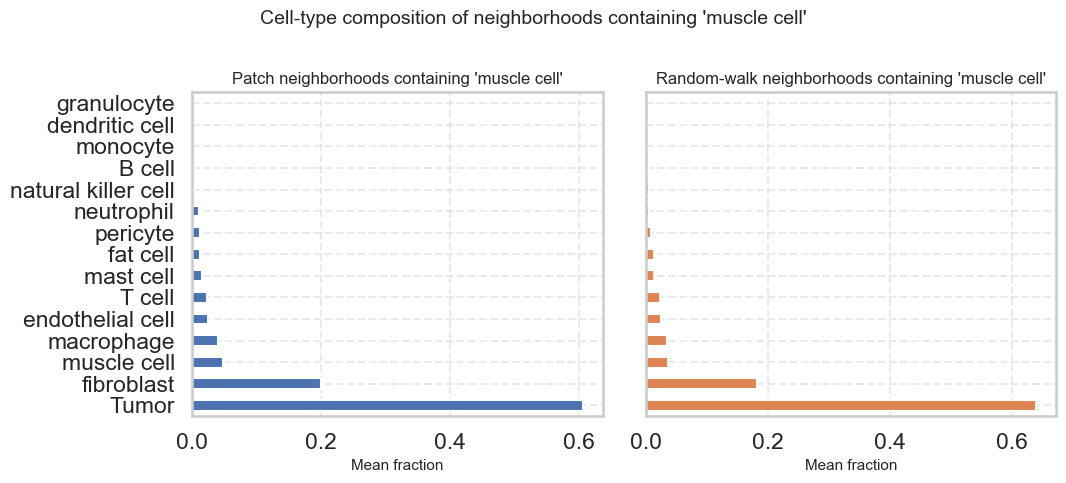

In [291]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
target_celltype = "muscle cell"
n_sample = 200
# ----------------------------------------

# Randomly sample neighborhoods
sample_patch = np.random.choice(patch_assign['patch_id'].unique(), size=n_sample, replace=False)
sample_rw = np.random.choice(neigh_assign['neighborhood_id'].unique(), size=n_sample, replace=False)


def neighborhood_composition_with_celltype(assign_df, adata, id_col, cell_col, target_celltype):
    """
    Summarize cell-type composition of neighborhoods that contain the given target cell type.
    """
    results = []

    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]

        if "cell_type" not in sub.columns:
            continue

        celltypes = sub["cell_type"].value_counts()

        # Only include neighborhoods that contain the target cell type
        if target_celltype not in celltypes.index:
            continue

        total = celltypes.sum()
        freqs = (celltypes / total).to_dict()
        freqs["nb_id"] = nb_id
        results.append(freqs)

    return pd.DataFrame(results).fillna(0)


# Compute for sampled neighborhoods only
patch_subset = patch_assign[patch_assign["patch_id"].isin(sample_patch)]
rw_subset = neigh_assign[neigh_assign["neighborhood_id"].isin(sample_rw)]

df_patch_comp = neighborhood_composition_with_celltype(patch_subset, adata, "patch_id", "cell", target_celltype)
df_rw_comp = neighborhood_composition_with_celltype(rw_subset, adata, "neighborhood_id", "cell", target_celltype)

# Compute mean composition across those neighborhoods
mean_patch = df_patch_comp.drop(columns="nb_id").mean().sort_values(ascending=False)
mean_rw = df_rw_comp.drop(columns="nb_id").mean().sort_values(ascending=False)

# ---------------- PLOT ----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

mean_patch.plot(kind="barh", ax=axes[0], color="#4c72b0")
axes[0].set_title(f"Patch neighborhoods containing '{target_celltype}'", fontsize=12)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean fraction", fontsize=11)
axes[0].grid(alpha=0.4, linestyle="--")

mean_rw.plot(kind="barh", ax=axes[1], color="#dd8452")
axes[1].set_title(f"Random-walk neighborhoods containing '{target_celltype}'", fontsize=12)
axes[1].set_xlabel("Mean fraction", fontsize=11)
axes[1].grid(alpha=0.4, linestyle="--")

plt.suptitle(f"Cell-type composition of neighborhoods containing '{target_celltype}'", fontsize=14)
plt.tight_layout()
plt.show()


        method  hits  total    percent
0        Patch     8     92   8.695652
1  Random walk    21    136  15.441176


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/1359571290.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=res, x="method", y="percent", palette=["#4c72b0", "#dd8452"])


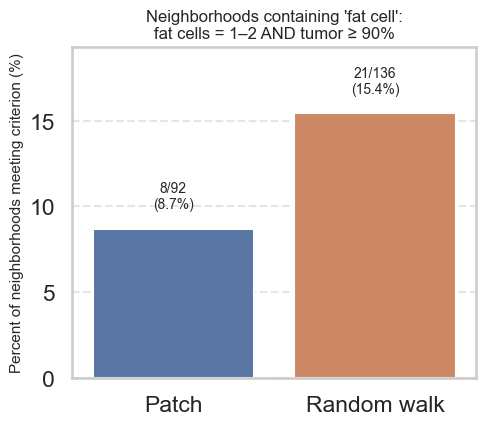

In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========= CONFIG =========
target_celltype = "fat cell"   # 目标细胞类型
tumor_label = "tumor"          # tumor 在 adata.obs['cell_type'] 里的标签（不区分大小写）
n_sample = 500
rng = np.random.default_rng(42)  # 可复现随机数
# =========================

def evaluate_neighborhoods(assign_df, id_col, cell_col, adata, target_celltype, tumor_label):
    """
    对传入的 assign_df（只包含已抽样到的 nb_id）进行评估：
    - 只考虑包含 target_celltype 的 neighborhood
    - 条件：fat cell 数量 ∈ {1,2} 且 tumor 占比 ≥ 0.9
    返回：命中数量、总数量
    """
    target_lower = target_celltype.lower()
    tumor_lower  = tumor_label.lower()

    hits = 0
    total = 0

    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]

        if "cell_type" not in sub.columns or sub.empty:
            continue

        # 统一小写比较，避免大小写/类别问题
        cell_types_lower = sub["cell_type"].astype(str).str.lower()

        # 只统计包含 target 的 neighborhood
        if not (cell_types_lower == target_lower).any():
            continue

        total += 1
        n_total = len(cell_types_lower)
        n_fat   = (cell_types_lower == target_lower).sum()
        n_tumor = (cell_types_lower == tumor_lower).sum()
        frac_tumor = n_tumor / n_total if n_total > 0 else 0.0

        if (n_fat in (1, 2, 3)) and (frac_tumor >= 0.80):
            hits += 1

    return hits, total

# ---- 抽样（各 1000 个）----
patch_ids_all = patch_assign["patch_id"].unique()
rw_ids_all    = neigh_assign["neighborhood_id"].unique()

patch_ids_sample = rng.choice(patch_ids_all, size=min(n_sample, len(patch_ids_all)), replace=False)
rw_ids_sample    = rng.choice(rw_ids_all,    size=min(n_sample, len(rw_ids_all)),    replace=False)

patch_subset = patch_assign[patch_assign["patch_id"].isin(patch_ids_sample)]
rw_subset    = neigh_assign[neigh_assign["neighborhood_id"].isin(rw_ids_sample)]

# ---- 评估 ----
hits_patch, total_patch = evaluate_neighborhoods(
    assign_df=patch_subset,
    id_col="patch_id",
    cell_col="cell",
    adata=adata,
    target_celltype=target_celltype,
    tumor_label=tumor_label
)

hits_rw, total_rw = evaluate_neighborhoods(
    assign_df=rw_subset,
    id_col="neighborhood_id",
    cell_col="cell",
    adata=adata,
    target_celltype=target_celltype,
    tumor_label=tumor_label
)

# 结果汇总
res = pd.DataFrame({
    "method": ["Patch", "Random walk"],
    "hits":   [hits_patch, hits_rw],
    "total":  [total_patch, total_rw],
})
res["percent"] = np.where(res["total"] > 0, res["hits"] / res["total"] * 100, np.nan)
print(res)

# ---- 画两个柱子（百分比），并标注 hits/total 与百分比 ----
plt.figure(figsize=(5.2, 4.6))
ax = sns.barplot(data=res, x="method", y="percent", palette=["#4c72b0", "#dd8452"])

ax.set_ylabel("Percent of neighborhoods meeting criterion (%)", fontsize=11)
ax.set_xlabel("")
ax.set_title(f"Neighborhoods containing '{target_celltype}':\n"
             f"fat cells = 1–2 AND tumor ≥ 90%", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# 标注数值
for i, row in res.iterrows():
    y = row["percent"]
    label = f"{int(row['hits'])}/{int(row['total'])}\n({y:.1f}%)" if pd.notnull(y) else "0/0\n(n/a)"
    ax.text(i, (0 if pd.isna(y) else y) + 1.0, label, ha="center", va="bottom", fontsize=10)

plt.ylim(0, max(5, np.nanmax(res["percent"]) * 1.25))  # 留出标注空间
plt.tight_layout()
plt.show()


        method  hits  total  percent
0        Patch   172   1000     17.2
1  Random walk   212   1000     21.2


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/2146862590.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=res, x="method", y="percent", palette=["#4c72b0", "#dd8452"])


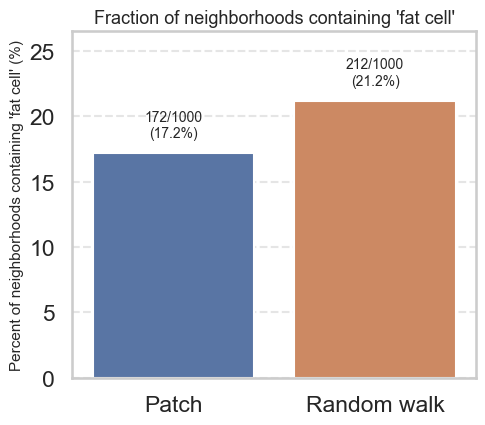

In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_celltype = "fat cell"
n_sample = 1000
rng = np.random.default_rng(42)

def count_neighborhoods_with_target(assign_df, id_col, cell_col, adata, target_celltype):
    """
    返回 (包含目标细胞的neighborhood数, 抽样总数)
    """
    target_lower = target_celltype.lower()
    hits = 0
    total = 0

    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]
        if "cell_type" not in sub.columns or sub.empty:
            continue

        celltypes_lower = sub["cell_type"].astype(str).str.lower()
        total += 1
        if (celltypes_lower == target_lower).any():
            hits += 1

    return hits, total


# --- 抽样 ---
patch_ids = rng.choice(patch_assign["patch_id"].unique(), size=n_sample, replace=False)
rw_ids = rng.choice(neigh_assign["neighborhood_id"].unique(), size=n_sample, replace=False)

patch_subset = patch_assign[patch_assign["patch_id"].isin(patch_ids)]
rw_subset = neigh_assign[neigh_assign["neighborhood_id"].isin(rw_ids)]

# --- 统计 ---
hits_patch, total_patch = count_neighborhoods_with_target(patch_subset, "patch_id", "cell", adata, target_celltype)
hits_rw, total_rw = count_neighborhoods_with_target(rw_subset, "neighborhood_id", "cell", adata, target_celltype)

# --- 汇总 ---
res = pd.DataFrame({
    "method": ["Patch", "Random walk"],
    "hits": [hits_patch, hits_rw],
    "total": [total_patch, total_rw],
})
res["percent"] = res["hits"] / res["total"] * 100
print(res)

# --- 绘图 ---
plt.figure(figsize=(5.2, 4.6))
ax = sns.barplot(data=res, x="method", y="percent", palette=["#4c72b0", "#dd8452"])

ax.set_ylabel(f"Percent of neighborhoods containing '{target_celltype}' (%)", fontsize=11)
ax.set_xlabel("")
ax.set_title(f"Fraction of neighborhoods containing '{target_celltype}'", fontsize=13)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# 标注数字
for i, row in res.iterrows():
    label = f"{int(row['hits'])}/{int(row['total'])}\n({row['percent']:.1f}%)"
    ax.text(i, row["percent"] + 1, label, ha="center", va="bottom", fontsize=10)

plt.ylim(0, max(5, np.nanmax(res["percent"]) * 1.25))
plt.tight_layout()
plt.show()


        method  hits  total  percent
0        Patch   352   1000     35.2
1  Random walk   483   1000     48.3


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/771246936.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_frac, x="method", y="percent", palette=["#4c72b0", "#dd8452"])


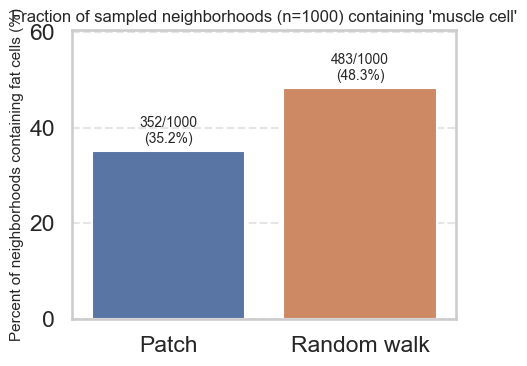

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
target_celltype = "muscle cell"
n_sample = 1000
rng = np.random.default_rng(42)
# ----------------------------------------

def fraction_with_target(assign_df, id_col, cell_col, adata, target_celltype):
    """Return number and fraction of neighborhoods containing the target cell type."""
    target_lower = target_celltype.lower()
    total = 0
    has_target = 0

    for nb_id in assign_df[id_col].unique():
        nb_cells = assign_df.loc[assign_df[id_col] == nb_id, cell_col].astype(str)
        sub = adata.obs.loc[adata.obs_names.isin(nb_cells)]
        if "cell_type" not in sub.columns or sub.empty:
            continue
        total += 1
        cell_types_lower = sub["cell_type"].astype(str).str.lower()
        if (cell_types_lower == target_lower).any():
            has_target += 1

    frac = has_target / total if total > 0 else np.nan
    return has_target, total, frac


# ---- sampling (each 1000) ----
patch_ids = rng.choice(patch_assign["patch_id"].unique(), size=min(n_sample, len(patch_assign["patch_id"].unique())), replace=False)
rw_ids = rng.choice(neigh_assign["neighborhood_id"].unique(), size=min(n_sample, len(neigh_assign["neighborhood_id"].unique())), replace=False)

patch_subset = patch_assign[patch_assign["patch_id"].isin(patch_ids)]
rw_subset = neigh_assign[neigh_assign["neighborhood_id"].isin(rw_ids)]

# ---- compute fractions ----
hits_patch, total_patch, frac_patch = fraction_with_target(patch_subset, "patch_id", "cell", adata, target_celltype)
hits_rw, total_rw, frac_rw = fraction_with_target(rw_subset, "neighborhood_id", "cell", adata, target_celltype)

df_frac = pd.DataFrame({
    "method": ["Patch", "Random walk"],
    "hits": [hits_patch, hits_rw],
    "total": [total_patch, total_rw],
    "percent": [frac_patch * 100, frac_rw * 100]
})
print(df_frac)

# ---- plot ----
plt.figure(figsize=(5, 4))
ax = sns.barplot(data=df_frac, x="method", y="percent", palette=["#4c72b0", "#dd8452"])

ax.set_ylabel("Percent of neighborhoods containing fat cells (%)", fontsize=11)
ax.set_xlabel("")
ax.set_title(f"Fraction of sampled neighborhoods (n={n_sample}) containing '{target_celltype}'", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# add text labels
for i, row in df_frac.iterrows():
    ax.text(i, row["percent"] + 1, f"{row['hits']}/{row['total']}\n({row['percent']:.1f}%)",
            ha="center", va="bottom", fontsize=10)

plt.ylim(0, max(5, np.nanmax(df_frac["percent"]) * 1.25))
plt.tight_layout()
plt.show()


# Checking code

In [196]:
# ----------------------------------------------------------------------
# Environment: avoid multi-OpenMP conflicts on macOS/conda stacks
# ----------------------------------------------------------------------
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
os.environ.setdefault("NUMBA_NUM_THREADS", "1")

# ----------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------
import argparse
from typing import List, Tuple
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse as sp
from numba import njit
import warnings

# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------
def _to_list_genes(s: str) -> List[str]:
    """Split gene string into list. Treat underscores as multi-subunit separators."""
    s = str(s).strip()
    if "_" in s:
        return [g.strip() for g in s.split("_") if g.strip()]
    return [s]

def _prepare_lr_table(lr_df: pd.DataFrame, adata: ad.AnnData) -> pd.DataFrame:
    """
    Keep only LR rows whose all ligand & receptor genes are present in adata.
    Adds: lig_list, rec_list
    """
    df = lr_df.copy()
    assert {"ligand", "receptor"}.issubset(df.columns), "LR CSV must have 'ligand' and 'receptor' columns"
    df["lig_list"] = df["ligand"].apply(_to_list_genes)
    df["rec_list"] = df["receptor"].apply(_to_list_genes)

    gene_set = set(map(str, adata.var_names))
    keep = []
    for _, row in df.iterrows():
        lig_ok = all(g in gene_set for g in row["lig_list"])
        rec_ok = all(g in gene_set for g in row["rec_list"])
        keep.append(lig_ok and rec_ok)
    return df.loc[keep].reset_index(drop=True)

# ----------------------------------------------------------------------
# Expression masks (ligand AND, receptor AND)
# ----------------------------------------------------------------------
def compute_lr_masks_optimized(
    adata: ad.AnnData, 
    lr_df: pd.DataFrame,
    expr_min: int = 0
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Optimized computation of ligand/receptor expression masks.
    - Ligand: ALL genes must be expressed
    - Receptor: ALL genes must be expressed
    
    Returns:
        lig_can_send: (n_cells, n_LR) bool
        rec_can_recv: (n_cells, n_LR) bool
        lr_df_filtered: filtered LR dataframe
    """
    lr_df_filtered = _prepare_lr_table(lr_df, adata)
    if len(lr_df_filtered) == 0:
        return np.zeros((adata.n_obs, 0), dtype=bool), np.zeros((adata.n_obs, 0), dtype=bool), lr_df_filtered
    
    n_cells = adata.n_obs
    n_lr = len(lr_df_filtered)
    gene_to_idx = {g: i for i, g in enumerate(adata.var_names)}
    
    # index lists per LR
    all_genes_needed = set()
    lig_idx_per_lr, rec_idx_per_lr = [], []
    for _, row in lr_df_filtered.iterrows():
        lig_idx = [gene_to_idx[g] for g in row["lig_list"] if g in gene_to_idx]
        rec_idx = [gene_to_idx[g] for g in row["rec_list"] if g in gene_to_idx]
        # if anything missing, mark empty (no one can satisfy)
        if len(lig_idx) != len(row["lig_list"]) or len(rec_idx) != len(row["rec_list"]):
            lig_idx, rec_idx = [], []
        lig_idx_per_lr.append(lig_idx)
        rec_idx_per_lr.append(rec_idx)
        all_genes_needed.update(lig_idx)
        all_genes_needed.update(rec_idx)

    if len(all_genes_needed) == 0:
        warnings.warn("No valid genes found in LR database after filtering")
        return np.zeros((n_cells, 0), dtype=bool), np.zeros((n_cells, 0), dtype=bool), lr_df_filtered
    
    # one-shot extraction to dense bool
    gene_list = sorted(all_genes_needed)
    print(f"Extracting expression for {len(gene_list)} unique genes...")
    if sp.issparse(adata.X):
        X_bool = adata.X[:, gene_list].toarray() > expr_min
    else:
        X_bool = np.asarray(adata.X[:, gene_list]) > expr_min
    g2loc = {g: i for i, g in enumerate(gene_list)}

    lig_can_send = np.zeros((n_cells, n_lr), dtype=bool)
    rec_can_recv = np.zeros((n_cells, n_lr), dtype=bool)

    print(f"Computing masks for {n_lr} LR pairs...")
    for j, (L_idx, R_idx) in enumerate(zip(lig_idx_per_lr, rec_idx_per_lr)):
        if L_idx:
            cols = [g2loc[g] for g in L_idx]
            lig_can_send[:, j] = np.all(X_bool[:, cols], axis=1)
        if R_idx:
            cols = [g2loc[g] for g in R_idx]
            rec_can_recv[:, j] = np.all(X_bool[:, cols], axis=1)
        if (j + 1) % 200 == 0:
            print(f"  Processed {j + 1}/{n_lr} LR pairs...")
    return lig_can_send, rec_can_recv, lr_df_filtered

# ----------------------------------------------------------------------
# CSR/CSC adjacency builders
# ----------------------------------------------------------------------
def build_sender_csr(lig_can_send: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build CSR-like adjacency for senders.
    Returns:
        indices: concatenated LR indices
        indptr: length n_cells+1, row slice is indices[indptr[i]:indptr[i+1]]
    """
    rows, cols = np.nonzero(lig_can_send)
    n_cells = lig_can_send.shape[0]
    indptr = np.zeros(n_cells + 1, dtype=np.int64)
    np.add.at(indptr, rows + 1, 1)
    np.cumsum(indptr, out=indptr)
    indices = np.empty(len(cols), dtype=np.int32)
    counter = indptr.copy()
    for r, c in zip(rows, cols):
        pos = counter[r]
        indices[pos] = c
        counter[r] += 1
    return indices, indptr

def build_receiver_csc(rec_can_recv: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build CSC-like adjacency for receivers.
    Returns:
        indices: concatenated cell indices
        indptr: length n_lr+1, column slice is indices[indptr[j]:indptr[j+1]]
    """
    rows, cols = np.nonzero(rec_can_recv)
    n_lr = rec_can_recv.shape[1]
    indptr = np.zeros(n_lr + 1, dtype=np.int64)
    np.add.at(indptr, cols + 1, 1)
    np.cumsum(indptr, out=indptr)
    indices = np.empty(len(rows), dtype=np.int32)
    counter = indptr.copy()
    for r, c in zip(rows, cols):
        pos = counter[c]
        indices[pos] = r
        counter[c] += 1
    return indices, indptr


In [198]:
lr_df =  pd.read_csv('../data/LRdatabase/CellPhoneDBv5.0.human.csv')

In [203]:
lr_df_filtered = _prepare_lr_table(lr_df, adata)
lr_df_filtered

,ligand,receptor,classification,directionality,id_cp_interaction,signaling_type,lig_list,rec_list
0,CDH1,ITGAE_ITGB7,Adhesion by Cadherin,Adhesion-Adhesion,CPI-SC09D882C18,Cell-Cell Contact,[CDH1],"[ITGAE, ITGB7]"
1,CDH1,KLRG1,Adhesion by Cadherin,Ligand-Receptor,CPI-SS0CC5DCE80,Cell-Cell Contact,[CDH1],[KLRG1]
2,CDH2,CDH2,Adhesion by Cadherin,Adhesion-Adhesion,CPI-SS0EE09A201,Cell-Cell Contact,[CDH2],[CDH2]
3,CDH2,FCER2,Adhesion by Cadherin,Ligand-Receptor,CPI-SS0ADFF0666,Cell-Cell Contact,[CDH2],[FCER2]
4,CDH3,CDH3,Adhesion by Cadherin,Adhesion-Adhesion,CPI-SS0DA0F5556,Cell-Cell Contact,[CDH3],[CDH3]
...,...,...,...,...,...,...,...,...
1010,PTGIS,PTGIR,NaN,Ligand-Receptor,CPI-CS09A35DD21,Secreted Signaling,[PTGIS],[PTGIR]
1011,SPN,SIGLEC1,NaN,Ligand-Receptor,CPI-SS02A170A99,Cell-Cell Contact,[SPN],[SIGLEC1]
1012,THPO,MPL,NaN,Ligand-Receptor,CPI-SS0DC2DD9D7,Secreted Signaling,[THPO],[MPL]
1013,TRH,TRHR,NaN,Ligand-Receptor,CPI-SS00F69C501,Secreted Signaling,[TRH],[TRHR]


In [199]:
print("Computing LR expression masks (optimized)...")
lig_can_send, rec_can_recv, lr_df_filtered = compute_lr_masks_optimized(
    adata, lr_df, 0
)
# if lr_df_filtered.empty or lig_can_send.shape[1] == 0:
#     print("WARNING: No valid LR pairs after filtering")
#     # Use obs.index directly
#     cell_ids = adata.obs.index.astype(str).values
#     df = pd.DataFrame({"cell": cell_ids, "neighborhood_id": np.arange(adata.n_obs, dtype=int)})
#     return df, adata.n_obs


Computing LR expression masks (optimized)...
Extracting expression for 690 unique genes...
Computing masks for 1015 LR pairs...
  Processed 200/1015 LR pairs...
  Processed 400/1015 LR pairs...
  Processed 600/1015 LR pairs...
  Processed 800/1015 LR pairs...
  Processed 1000/1015 LR pairs...


In [213]:
lig_can_send.shape, rec_can_recv.shape, lr_df_filtered.shape

((1576161, 1015), (1576161, 1015), (1015, 8))

In [212]:
# stats
n_senders = int(np.sum(np.any(lig_can_send, axis=1)))
n_receivers = int(np.sum(np.any(rec_can_recv, axis=1)))
print(f"  {n_senders}/{adata.n_obs} cells can send at least one ligand")
print(f"  {n_receivers}/{adata.n_obs} cells can receive at least one signal")

  1538506/1576161 cells can send at least one ligand
  1517623/1576161 cells can receive at least one signal


In [225]:
rows, cols = np.nonzero(lig_can_send)
n_cells = lig_can_send.shape[0]
indptr = np.zeros(n_cells + 1, dtype=np.int64)
np.add.at(indptr, rows + 1, 1)
np.cumsum(indptr, out=indptr)
indices = np.empty(len(cols), dtype=np.int32)
counter = indptr.copy()
for r, c in zip(rows, cols):
    pos = counter[r]
    indices[pos] = c
    counter[r] += 1

In [214]:
# adjacency
print("Building sender/receiver adjacency (CSR/CSC)...")
sender_idx, sender_ptr = build_sender_csr(lig_can_send)
recv_idx, recv_ptr = build_receiver_csc(rec_can_recv)

Building sender/receiver adjacency (CSR/CSC)...


In [236]:
sender_idx.shape, sender_ptr.shape, recv_idx.shape, recv_ptr.shape

((45225575,), (1576162,), (35099772,), (1016,))

In [227]:
# 查询细胞1能发送哪些LR
cell_id = 1
start = sender_ptr[cell_id]      # = 2
end = sender_ptr[cell_id + 1]    # = 4
lrs_can_send = sender_idx[start:end]  # = [1, 2]
print(f"细胞{cell_id}能发送LR: {lrs_can_send}")

细胞1能发送LR: [ 25  45 141 150 159 168 255 288 291 295 298 620 650 684 686 688 690 707
 713 715 717 729 856 860 862 978 990]


In [243]:
# 查询LR能被哪些细胞接收
lr_id = 25
start = recv_ptr[lr_id]       # = 4
end = recv_ptr[lr_id + 1]     # = 6
cells_can_receive = recv_idx[start:end]  # = [0, 1]
print(f"LR{lr_id}能被细胞接收: {cells_can_receive}")

LR25能被细胞接收: [     26      49      59 ... 1574998 1575093 1575938]


In [241]:
recv_idx

array([   9857,   13001,   15320, ..., 1576068, 1576100, 1576133],
      dtype=int32)

In [244]:
np.random.seed(0)
n_cells = sender_ptr.size - 1
assignments = np.full(n_cells, -1, dtype=np.int32)
nb_id = 0

assignments

array([-1, -1, -1, ..., -1, -1, -1], dtype=int32)

In [247]:
sender_ptr

array([       0,       38,       65, ..., 45225563, 45225575, 45225575])

In [248]:
# cells that can send at least one LR
can_send = np.zeros(n_cells, dtype=np.bool_)
for i in range(n_cells):
    can_send[i] = (sender_ptr[i+1] > sender_ptr[i])
sender_cells = np.where(can_send)[0]
sender_cells

array([      0,       1,       2, ..., 1576157, 1576158, 1576159])

In [249]:
sender_cells.shape

(1538506,)

In [250]:
# shuffle seeds
for i in range(sender_cells.size - 1, 0, -1):
    j = np.random.randint(i + 1)
    tmp = sender_cells[i]
    sender_cells[i] = sender_cells[j]
    sender_cells[j] = tmp

In [251]:
sender_cells

array([ 157481,  684749,  296322, ...,  120434, 1518967,  316164])

In [259]:
seed_cell = sender_cells[0]
seed_cell

157481

In [262]:
nb_cells = np.zeros(20, dtype=np.int32)
nb_cells

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [263]:
nb_size = 0
nb_cells[nb_size] = seed_cell
assignments[seed_cell] = nb_id
nb_size += 1

In [258]:
current = seed_cell
s_beg = sender_ptr[current]
s_end = sender_ptr[current + 1]
s_beg, s_end

(3466992, 3467011)

In [260]:
sender_idx[s_beg:s_end]

array([  25,   71,   97,  101,  102,  250,  668,  670,  672,  695,  696,
        802,  803,  804,  805,  806,  978,  985, 1011], dtype=int32)

In [266]:
nb_cells[(1 + 0) % 1]

157481

In [265]:
nb_cells

array([157481,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0], dtype=int32)

In [268]:
tried = np.zeros(s_end - s_beg, dtype=np.bool_)
tried

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [270]:
untried = np.where(~tried)[0]
pick = untried[np.random.randint(untried.size)]
pick

12

In [272]:
lr_idx = sender_idx[s_beg + pick]
tried[pick] = True
lr_idx

803

In [274]:
lr_df.loc[lr_idx]

ligand                      GPHA2_GPHB5
receptor                           TSHR
classification                      NaN
directionality          Ligand-Receptor
id_cp_interaction       CPI-CS08AEE70BD
signaling_type       Secreted Signaling
Name: 803, dtype: object

In [279]:
r_beg = recv_ptr[lr_idx]
r_end = recv_ptr[lr_idx + 1]
r_beg, r_end

(28174839, 28187158)

In [280]:
local_trials = min(16, r_end - r_beg)
local_trials

16

In [281]:
ridx = r_beg + np.random.randint(r_end - r_beg)
nxt = recv_idx[ridx]
nxt

1396897

In [283]:
nb_cells[nb_size] = nxt
nb_cells

array([ 157481, 1396897,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0], dtype=int32)

In [285]:
assignments[nxt] = nb_id

In [286]:
assignments

array([-1, -1, -1, ..., -1, -1, -1], dtype=int32)

In [287]:
nb_cells

array([ 157481, 1396897,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0], dtype=int32)

In [288]:
# 模拟偏差效果
import numpy as np

def simulate_bias_effect(n_cells=1000, n_lr=100, n_neighborhoods=50):
    """模拟采样偏差对邻域构建的影响"""
    
    # 假设细胞的连接度服从幂律分布
    cell_degrees = np.random.pareto(a=2.0, size=n_cells) * 10
    
    # 记录每个细胞被选中的概率
    selection_prob = np.zeros(n_cells)
    
    for nb in range(n_neighborhoods):
        available = np.where(selection_prob == 0)[0]
        if len(available) == 0:
            break
            
        # 基于连接度的采样概率
        probs = cell_degrees[available] / cell_degrees[available].sum()
        
        # 选择20个细胞
        selected = np.random.choice(available, 
                                  size=min(20, len(available)), 
                                  replace=False, 
                                  p=probs)
        selection_prob[selected] = nb + 1
    
    return selection_prob, cell_degrees

# 分析结果
selection, degrees = simulate_bias_effect()
selected_mask = selection > 0

print(f"高连接度细胞（top 10%）被选中率: {selected_mask[degrees > np.percentile(degrees, 90)].mean():.2%}")
print(f"低连接度细胞（bottom 10%）被选中率: {selected_mask[degrees < np.percentile(degrees, 10)].mean():.2%}")

高连接度细胞（top 10%）被选中率: 100.00%
低连接度细胞（bottom 10%）被选中率: 100.00%


In [ ]:
for s in range(sender_cells.size):
    seed_cell = sender_cells[s]
    if assignments[seed_cell] != -1:
        continue

    # start new neighborhood
    nb_cells = np.zeros(20, dtype=np.int32)
    nb_size = 0
    nb_cells[nb_size] = seed_cell
    assignments[seed_cell] = nb_id
    nb_size += 1

    current = seed_cell
    attempts = 0
    max_attempts = 20 * 20

    while nb_size < 20 and attempts < max_attempts:
        attempts += 1

        # sender LR slice
        s_beg = sender_ptr[current]
        s_end = sender_ptr[current + 1]
        if s_end == s_beg:
            # pick another sender inside the neighborhood
            found_sender = False
            if nb_size > 0:
                start = np.random.randint(nb_size)
                for k in range(nb_size):
                    cand = nb_cells[(start + k) % nb_size]
                    if sender_ptr[cand + 1] > sender_ptr[cand]:
                        current = cand
                        found_sender = True
                        break
            if not found_sender:
                break
            continue

In [166]:
from scipy import stats

# Extract data
a1 = df_summary["avg_degree"].dropna().values
a2 = df_summary_rw["avg_degree"].dropna().values
d1 = df_summary["density"].dropna().values
d2 = df_summary_rw["density"].dropna().values

# Mann–Whitney U test (non-parametric)
stat_avg, p_avg = stats.mannwhitneyu(a1, a2, alternative="two-sided")
stat_den, p_den = stats.mannwhitneyu(d1, d2, alternative="two-sided")

print(f"Average degree: U={stat_avg:.3f}, p-value={p_avg:.4g}")
print(f"Density:        U={stat_den:.3f}, p-value={p_den:.4g}")


Average degree: U=14236.000, p-value=6.18e-07
Density:        U=19311.500, p-value=0.5517


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/534015618.py:88: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs["cell_type"]):
/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/534015618.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(ct):


Neighborhood 19018: nodes=9, edges=80, LR rows used=110


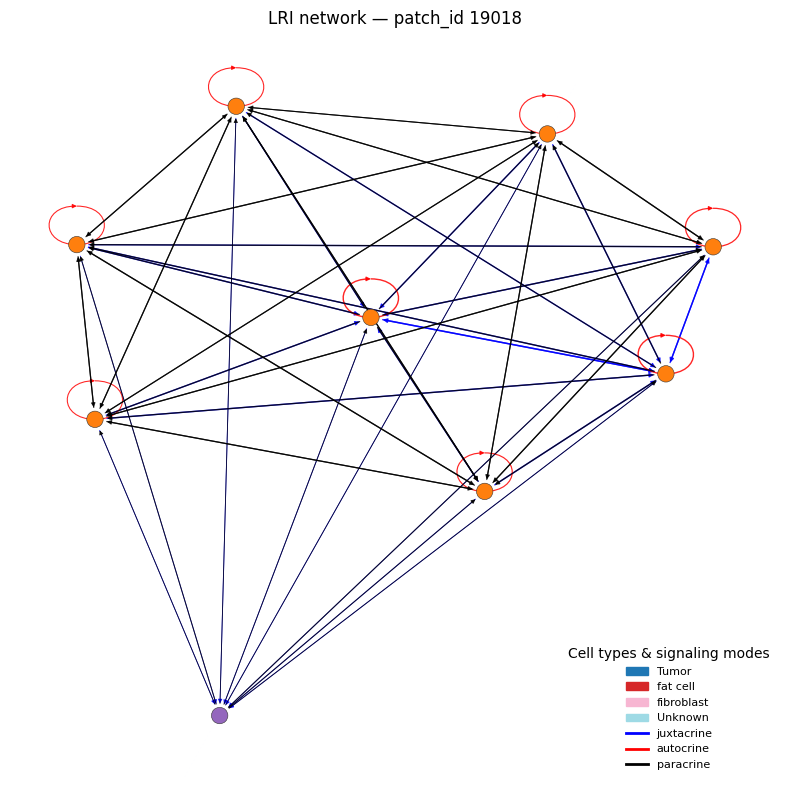

In [137]:
G, pos, cmap = plot_lri_network(
    cell_column="cell",
    nbh_id_column="patch_id",
    neigh_assign=patch_assign,
    adata=adata,
    cellphone=cellphone,
    nh_id=19018,
    # optional tweaks:
    node_size=140,
    spring_k=1.0,          # spread more
    figsize=(8, 8)
)

/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/534015618.py:88: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs["cell_type"]):
/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/534015618.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(ct):


Neighborhood 19018: nodes=20, edges=289, LR rows used=202


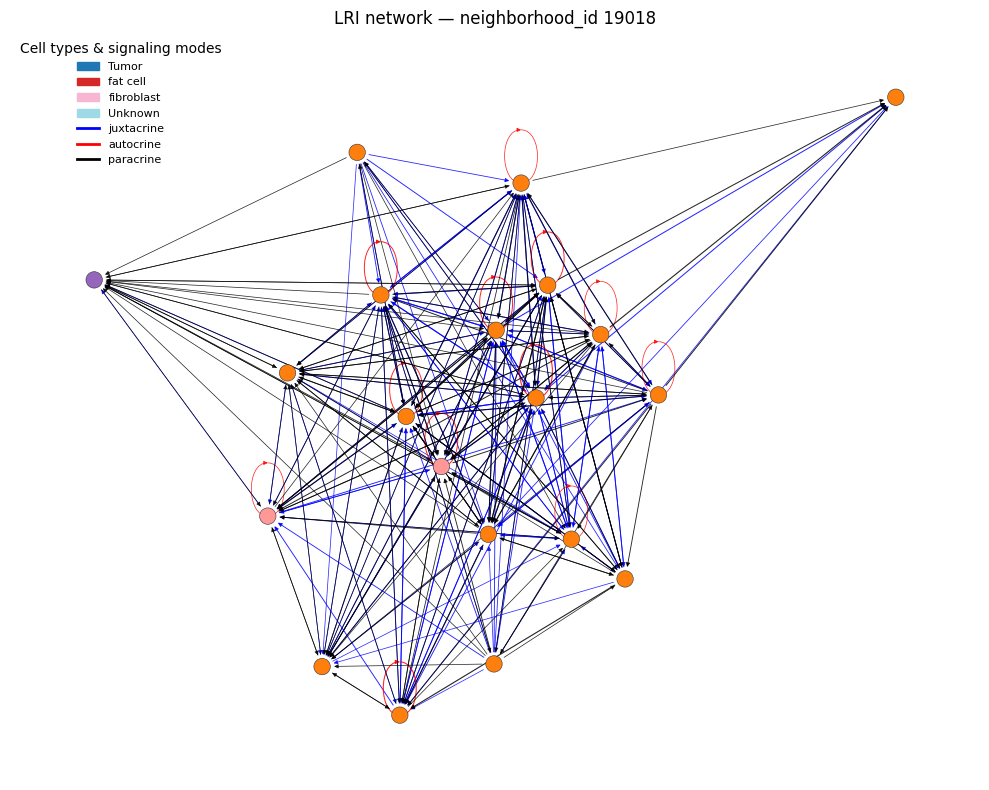

In [133]:
G, pos, cmap = plot_lri_network(
    cell_column="cell",
    nbh_id_column="neighborhood_id",
    neigh_assign=neigh_assign,
    adata=adata,
    cellphone=cellphone,
    nh_id=19018,
    # optional tweaks:
    node_size=140,
    spring_k=1.0,          # spread more
    figsize=(10, 8)
)

In [ ]:


summary = graph_connectivity_summary(G)
pd.Series(summary)

nodes                    9.000000
edges                   80.000000
components               1.000000
frac_giant_component     1.000000
avg_degree              17.777778
density                  1.111111
clustering               1.000000
dtype: float64

In [147]:
summary

{'nodes': 9,
 'edges': 80,
 'components': 1,
 'frac_giant_component': 1.0,
 'avg_degree': 17.77777777777778,
 'density': 1.1111111111111112,
 'clustering': 1.0}

In [111]:
adata.obs['cell_type'].cat.categories

Index(['B cell', 'T cell', 'Tumor', 'dendritic cell', 'endothelial cell',
       'fat cell', 'fibroblast', 'granulocyte', 'macrophage', 'mast cell',
       'monocyte', 'muscle cell', 'natural killer cell', 'neutrophil',
       'pericyte'],
      dtype='object')

In [112]:
colors = plt.get_cmap("tab20").colors

In [ ]:
# cluster map
# sankey plot
# model a poisson... on gene expression, to sample cells that are more likely to interact


In [92]:
list(cell_types)

['Tumor',
 'muscle cell',
 'T cell',
 'fibroblast',
 'endothelial cell',
 'mast cell']

In [88]:
type(adata_sub.obs['cell_type'].unique())

pandas.core.arrays.categorical.Categorical

/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_13249/774324641.py:38: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(cell_types):


Neighborhood 87972: nodes=23, edges=343, LR rows used=43


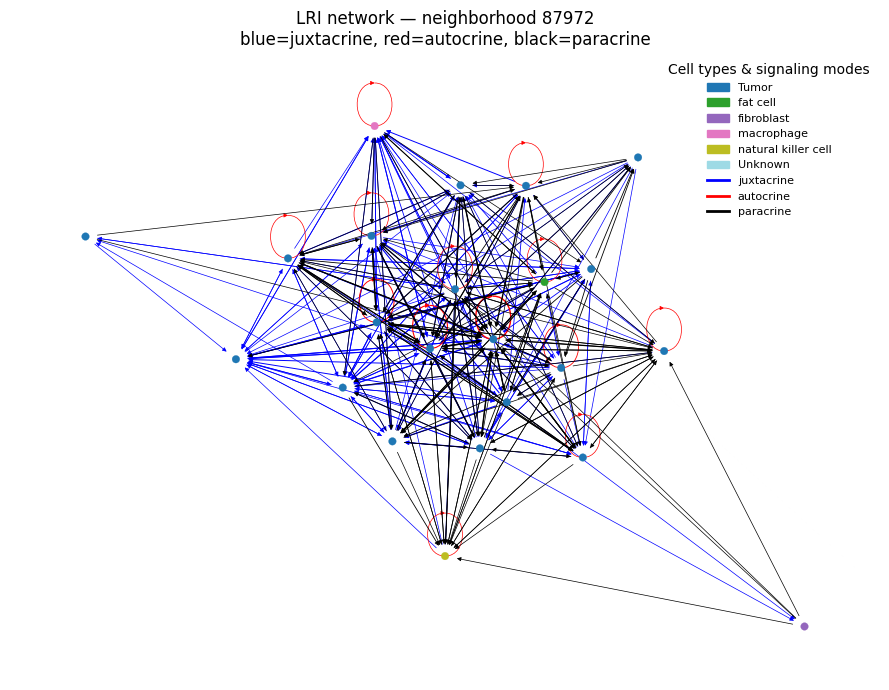

In [100]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# ---------- config ----------
nh_id = 87972
expr_thr = 0.0
require_all_receptor_subunits = True
require_all_ligand_subunits = False
# ----------------------------

# cells in the neighborhood
nh_cells = patch_assign.loc[patch_assign["patch_id"] == nh_id, "cell"].astype(str).values
adata_sub = adata[adata.obs_names.isin(nh_cells)]

# case-insensitive gene mapping
var_upper = pd.Series(adata_sub.var_names, index=[g.upper() for g in adata_sub.var_names]).groupby(level=0).first()

def map_present_genes(gene_str: str) -> list[str]:
    return [var_upper[g] for g in gene_str.split("_") if g.upper() in var_upper.index]

# matrix as DataFrame
X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
expr = pd.DataFrame(X, index=adata_sub.obs_names, columns=adata_sub.var_names)

def cells_expressing(genes: list[str], thr: float, require_all: bool) -> pd.Index:
    if len(genes) == 0:
        return pd.Index([])
    sub = expr[genes]
    mask = (sub > thr).all(axis=1) if require_all else (sub > thr).any(axis=1)
    return expr.index[mask]

# node colors by cell_type
if "cell_type" in adata_sub.obs:
    cell_types = adata_sub.obs["cell_type"].copy()
    if pd.api.types.is_categorical_dtype(cell_types):
        # ensure 'Unknown' is a valid category before filling
        if "Unknown" not in cell_types.cat.categories:
            cell_types = cell_types.cat.add_categories(["Unknown"])
    cell_types = cell_types.fillna("Unknown")
else:
    # if the column doesn’t exist, create a default one
    cell_types = pd.Series("Unknown", index=adata_sub.obs_names)

cats = pd.Categorical(cell_types)
palette = plt.get_cmap("tab20", len(cats.categories))
node_color_map = {ct: palette(i) for i, ct in enumerate(cats.categories)}
node_colors = [node_color_map[cell_types.loc[c]] for c in expr.index]

# build graph
G = nx.DiGraph()
G.add_nodes_from(expr.index)

# helper to add/accumulate edges
def add_edge(u, v, mode, ligand, receptor, signaling_type):
    if G.has_edge(u, v):
        G[u][v]["weight"] += 1
        G[u][v]["lris"].append((ligand, receptor, signaling_type, mode))
    else:
        G.add_edge(
            u, v,
            weight=1,
            mode=mode,  # last label added; for drawing we’ll group by mode anyway
            lris=[(ligand, receptor, signaling_type, mode)]
        )

used_rows = 0
for _, row in cellphone.iterrows():
    lig = str(row["ligand"])
    rec = str(row["receptor"])
    st  = str(row.get("signaling_type", ""))  # e.g., "Cell-Cell Contact", "Secreted Signaling", ...

    lig_genes = map_present_genes(lig)
    rec_genes = map_present_genes(rec)
    if len(lig_genes) == 0 or len(rec_genes) == 0:
        continue

    lig_cells = cells_expressing(lig_genes, expr_thr, require_all_ligand_subunits)
    rec_cells = cells_expressing(rec_genes, expr_thr, require_all_receptor_subunits)
    if len(lig_cells) == 0 or len(rec_cells) == 0:
        continue

    used_rows += 1

    if st == "Cell-Cell Contact":
        # juxtacrine ONLY, and skip same-cell expression (no autocrine counted here)
        for u in lig_cells:
            for v in rec_cells:
                if u == v:
                    continue  # explicitly skip same-cell case for contact
                add_edge(u, v, mode="juxtacrine", ligand=lig, receptor=rec, signaling_type=st)
    else:
        # non-contact: autocrine if same cell expresses L and R, else paracrine
        lig_set = set(lig_cells)
        rec_set = set(rec_cells)
        auto_cells = lig_set & rec_set
        para_pairs_u = lig_set
        para_pairs_v = rec_set

        # autocrine (self-loops)
        for c in auto_cells:
            add_edge(c, c, mode="autocrine", ligand=lig, receptor=rec, signaling_type=st)

        # paracrine (between different cells)
        for u in para_pairs_u:
            for v in para_pairs_v:
                if u == v:
                    continue
                add_edge(u, v, mode="paracrine", ligand=lig, receptor=rec, signaling_type=st)

print(f"Neighborhood {nh_id}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, LR rows used={used_rows}")

# ------- draw with requested colors -------
# edge colors by mode
edge_color_by_mode = {"juxtacrine": "blue", "autocrine": "red", "paracrine": "black"}

# layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(9, 7))

# draw nodes, colored by cell_type
nx.draw_networkx_nodes(
    G, pos,
    node_size=30,
    node_color=node_colors,
    linewidths=0.2
)

# draw edges grouped by mode so colors don’t get mixed
for mode, color in edge_color_by_mode.items():
    edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("mode") == mode]
    if len(edgelist) == 0:
        continue
    # make self-loops (autocrine) visible with a small arc
    if mode == "autocrine":
        nx.draw_networkx_edges(
            G, pos, edgelist=edgelist,
            edge_color=color,
            width=[0.4 + 0.1 * G[u][v]["weight"] for u, v in edgelist],
            arrowsize=6,
            connectionstyle="arc3,rad=0.25"
        )
    else:
        nx.draw_networkx_edges(
            G, pos, edgelist=edgelist,
            edge_color=color,
            width=[0.4 + 0.1 * G[u][v]["weight"] for u, v in edgelist],
            arrowsize=6
        )

plt.title(f"LRI network — neighborhood {nh_id}\nblue=juxtacrine, red=autocrine, black=paracrine")
plt.axis("off")

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
# Node color legend: one patch per cell type
node_legend_handles = [
    mpatches.Patch(color=color, label=ct)
    for ct, color in node_color_map.items()
]

# Edge color legend: one line per signaling mode
edge_legend_handles = [
    mlines.Line2D([], [], color=color, marker=None, linestyle='-', lw=2, label=mode)
    for mode, color in edge_color_by_mode.items()
]

# Combine both legends
plt.legend(
    handles=node_legend_handles + edge_legend_handles,
    loc="best",
    fontsize=8,
    frameon=False,
    title="Cell types & signaling modes"
)
plt.tight_layout()
plt.show()


Neighborhood 87972: nodes=23, edges=330, LR rows used=43


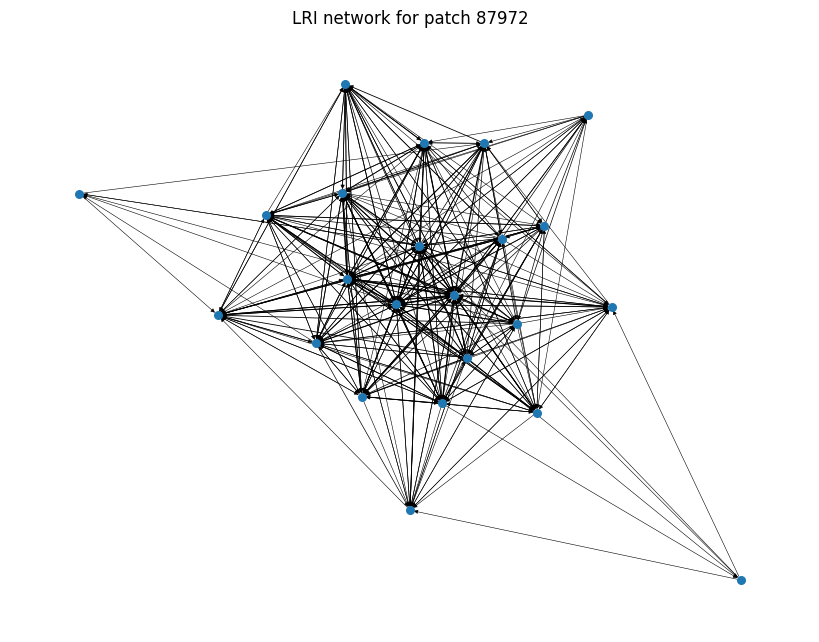

In [84]:
import networkx as nx
import numpy as np
import pandas as pd

# ---------- config ----------
nh_id = 87972
expr_thr = 0.0        # >0 counts = expressed; raise if you want stricter
require_all_receptor_subunits = True
require_all_ligand_subunits = False   # often fine to allow any ligand subunit
# ----------------------------

# cells in the neighborhood
nh_cells = patch_assign.loc[patch_assign["patch_id"] == nh_id, "cell"].astype(str).values
adata_sub = adata[adata.obs_names.isin(nh_cells)]

# build a case-insensitive mapping from GENE -> the exact var_name in adata
# (if duplicates after uppercasing, keep the first)
var_upper = pd.Series(adata_sub.var_names, index=[g.upper() for g in adata_sub.var_names]).groupby(level=0).first()

def map_present_genes(gene_str: str) -> list[str]:
    """Split 'ITGA2_ITGB1' -> ['ITGA2','ITGB1'], keep only those present in adata_sub.var_names (case-insensitive)."""
    genes = []
    for g in gene_str.split("_"):
        gu = g.upper()
        if gu in var_upper.index:
            genes.append(var_upper.loc[gu])
    return genes

# expression matrix as DataFrame (neighborhood is small so toarray() is ok)
X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
expr = pd.DataFrame(X, index=adata_sub.obs_names, columns=adata_sub.var_names)

def cells_expressing(genes: list[str], thr: float, require_all: bool) -> pd.Index:
    """Return cells with expression above threshold for ANY or ALL of the listed genes."""
    if len(genes) == 0:
        return pd.Index([])  # nothing present -> no cells
    sub = expr[genes]
    mask = (sub > thr).all(axis=1) if require_all else (sub > thr).any(axis=1)
    return expr.index[mask]

# build graph
G = nx.DiGraph()
G.add_nodes_from(expr.index)

# iterate LRIs with presence checks
kept = 0
for _, row in cellphone.iterrows():
    lig_genes = map_present_genes(str(row["ligand"]))
    rec_genes = map_present_genes(str(row["receptor"]))

    # skip pairs where required genes are missing from the dataset
    if len(rec_genes) == 0 or len(lig_genes) == 0:
        continue

    ligand_pos  = cells_expressing(lig_genes, expr_thr, require_all_ligand_subunits)
    receptor_pos = cells_expressing(rec_genes, expr_thr, require_all_receptor_subunits)
    if len(ligand_pos) == 0 or len(receptor_pos) == 0:
        continue

    # add directed edges; weight = number of LR pairs contributing (here 1 per row)
    for lcell in ligand_pos:
        for rcell in receptor_pos:
            if lcell == rcell:
                continue
            if G.has_edge(lcell, rcell):
                G[lcell][rcell]["weight"] += 1
                G[lcell][rcell]["lris"].append((row["ligand"], row["receptor"]))
            else:
                G.add_edge(
                    lcell, rcell,
                    weight=1,
                    lris=[(row["ligand"], row["receptor"])]
                )
    kept += 1

print(f"Neighborhood {nh_id}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, LR rows used={kept}")

# quick plot (for small neighborhoods)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=30, width=[0.3+0.1*G[u][v]["weight"] for u,v in G.edges()], arrowsize=6)
plt.title(f"LRI network for patch {nh_id}")
plt.show()


In [79]:
ligand_genes

['CDH1']